<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/Paper-Soyuz-ISS/blob/main/SPACEDOS_ISS_transition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS – ISS launch phase comparison (2019 vs 2020)

This notebook loads corrected CSV files `SPACEDOS_ISS2019_corrected.csv` and `SPACEDOS_ISS2020_corrected.csv` from Google Drive and plots **flux as a function of time** for the first ~7 days of each mission, highlighting key events through **docking**. Simultaneously, **orbital data (B, L-shell)** is loaded and L-shell is displayed on a secondary axis.

**Colab Optimization:**
- Only relevant columns (`corr_time`, `flux`, `ddsi`) are loaded to save memory.
- Data is limited to the first ~7 days using `nrows`.
- Orbital data is clipped to the first week post-launch.

## Key Events

**Soyuz MS-15 (2019)**
- Launch: 25.09.2019, 13:57:42.701 UTC
- Docking: 25.09.2019, 19:42:40 UTC

**Soyuz MS-17 (2020)**
- Launch: 14.10.2020, 05:45:04 UTC
- Docking: 14.10.2020, 08:48:43 UTC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
import gdown
%matplotlib inline

## 1. Data Download from Google Drive

In [2]:
# Google Drive file IDs – SPACEDOS corrected CSVs
FILE_ID_2019 = "1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g"   # SPACEDOS_ISS2019_corrected.csv
FILE_ID_2020 = "1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5"   # SPACEDOS_ISS2020_corrected.csv

# Google Drive file IDs – ISS orbital data (TSV: UTC[s], B, L)
ORBIT_ID_2019 = "1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0"   # ISS-coords-SPACEDOS-2019.tsv
ORBIT_ID_2020 = "1a9VYer0TCSZHT-Am-p3dG3Rvu4LwtvZ3"   # ISS-coords-SPACEDOS-2020.tsv

gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2019}",  "iss2019.csv",   quiet=False)
gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2020}",  "iss2020.csv",   quiet=False)
gdown.download(f"https://drive.google.com/uc?id={ORBIT_ID_2019}", "orbit2019.tsv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={ORBIT_ID_2020}", "orbit2020.tsv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g
From (redirected): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g&confirm=t&uuid=8397e77f-64a6-45a8-9d12-9ee15178e064
To: /content/iss2019.csv
100%|██████████| 951M/951M [00:09<00:00, 104MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5
From (redirected): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5&confirm=t&uuid=e66f6e9f-9d22-45f8-b1b4-21dc8a46e646
To: /content/iss2020.csv
100%|██████████| 344M/344M [00:03<00:00, 104MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0
From (redirected): https://drive.google.com/uc?id=1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0&confirm=t&uuid=7d1ea779-66ce-4ece-8c80-56617c63fb0d
To: /content/orbit2019.tsv
100%|██████████| 754M/754M [00:11<00:00, 63.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1a9VYer0TC

'orbit2020.tsv'

## 2. Memory-Efficient Data Loading

For 7 days with 10s integration, there are approximately 60,480 rows. We load ~80,000 rows per year to ensure a sufficient buffer.

In [3]:
# Load only necessary columns to save memory
USE_COLS = ["corr_time", "flux", "ddsi"]

# Number of rows – roughly 7 days (10s integration -> 8640 rows/day)
N_ROWS = 80_000

rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)
rc20 = pd.read_csv("iss2020.csv", usecols=USE_COLS, nrows=N_ROWS)

# Convert 'corr_time' to datetime, coercing errors to NaT, and then drop rows with NaT
initial_rows_rc19 = len(rc19)
rc19["corr_time"] = pd.to_datetime(rc19["corr_time"], utc=True, format='mixed', errors='coerce')
rc19.dropna(subset=['corr_time'], inplace=True)
dropped_rows_rc19 = initial_rows_rc19 - len(rc19)

initial_rows_rc20 = len(rc20)
rc20["corr_time"] = pd.to_datetime(rc20["corr_time"], utc=True, format='mixed', errors='coerce')
rc20.dropna(subset=['corr_time'], inplace=True)
dropped_rows_rc20 = initial_rows_rc20 - len(rc20)


print(f"Dropped {dropped_rows_rc19} rows from rc19 due to unparseable 'corr_time' values.")
print(f"Dropped {dropped_rows_rc20} rows from rc20 due to unparseable 'corr_time' values.")

print("2019 Data:", rc19.shape, " Range:", rc19["corr_time"].min(), "→", rc19["corr_time"].max())
print("2020 Data:", rc20.shape, " Range:", rc20["corr_time"].min(), "→", rc20["corr_time"].max())
print("\nMemory Usage:")
print("  rc19:", rc19.memory_usage(deep=True).sum() / 1e6, "MB")
print("  rc20:", rc20.memory_usage(deep=True).sum() / 1e6, "MB")

/tmp/ipykernel_1496/3695062714.py:7: DtypeWarning: Columns (259) have mixed types. Specify dtype option on import or set low_memory=False.
  rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)


Dropped 33623 rows from rc19 due to unparseable 'corr_time' values.
Dropped 0 rows from rc20 due to unparseable 'corr_time' values.
2019 Data: (46377, 3)  Range: 2019-09-25 00:00:03.955000+00:00 → 2019-10-02 03:19:24.415000+00:00
2020 Data: (80000, 3)  Range: 2020-10-13 08:03:04.437640+00:00 → 2020-10-23 04:24:33.455080+00:00

Memory Usage:
  rc19: 1.484064 MB
  rc20: 1.920132 MB


## 2b. Loading Orbital Data (B, L-shell)

The TSV contains `UTC` (seconds since epoch), `B` [nT], and `L` [Earth radii]. We clip the data to the first ~8 days post-launch to optimize memory usage.

In [4]:
def load_orbit(path, launch_time, days=8):
    """Loads orbit TSV, converts UTC to datetime, and clips to (launch - 1h, launch + days)."""
    cols = ["UTC", "B", "L"]
    orb = pd.read_csv(path, sep="\t", header=0, usecols=cols)
    orb["UTC"] = pd.to_datetime(orb["UTC"], unit="s", utc=True)
    tmin = launch_time - pd.Timedelta(hours=1)
    tmax = launch_time + pd.Timedelta(days=days)
    orb = orb.loc[(orb["UTC"] >= tmin) & (orb["UTC"] <= tmax)].reset_index(drop=True)
    return orb

LAUNCH_2019 = pd.Timestamp("2019-09-25 13:57:42.701", tz="UTC")
LAUNCH_2020 = pd.Timestamp("2020-10-14 05:45:04",     tz="UTC")

orbit19 = load_orbit("orbit2019.tsv", LAUNCH_2019, days=8)
orbit20 = load_orbit("orbit2020.tsv", LAUNCH_2020, days=8)

print("Orbit data loaded: orbit19 and orbit20 are now available.")

Orbit data loaded: orbit19 and orbit20 are now available.


## 3. Key Mission Event Definitions

Soyuz timeline – separation events are reference values based on typical Soyuz-FG and Soyuz-2.1a profiles.

In [48]:
# Soyuz MS-15 (2019) — Soyuz-FG
L19 = pd.Timestamp("2019-09-25 13:57:42.701", tz="UTC")
events_2019 = {
    "Launch":              L19,
    "20 km (+81-10 s)":  L19 + pd.Timedelta(seconds=81-10),
    "20 km (+81+10 s)":  L19 + pd.Timedelta(seconds=81+10),
    #"90 s":  L19 + pd.Timedelta(seconds=90),
    "Boosters sep (+01:58)":  pd.Timestamp("2019-09-25 13:59:40.501", tz="UTC"),  # Korolev cross
    "Fairing jettison (+02:40)":  L19 + pd.Timedelta(seconds=160),
    "Core stage sep (+04:47)": L19 + pd.Timedelta(minutes=4, seconds=47), # 287 seconds after launch
    "S/C separation (+08:48)": L19 + pd.Timedelta(minutes=8, seconds=48), # 528 seconds after launch
    #"SAA":  pd.Timestamp("2019-09-25 15:00:51.000", tz="UTC"),  # 1-st SAA
    "Docking":              pd.Timestamp("2019-09-25 19:42:40", tz="UTC"),
    "Undocking (MS-13)":   pd.Timestamp("2020-02-06 05:50:28", tz="UTC"),
    "Landing (MS-13)":     pd.Timestamp("2020-02-06 09:12:23", tz="UTC"),
}
# https://www.youtube.com/watch?v=je_6mdR06P0
# https://spaceflightnow.com/2018/10/13/soyuz-failure-probe-narrows-focus-on-collision-at-booster-separation/
#2:18 Launch, 4:19 boosters, 4:59 Jettison
#0:45 Launch, 2:41 boosters, 3:45 Jettison

# Soyuz MS-17 (2020) — Soyuz-2.1a, 2-orbit ultrafast rendezvous
L20 = pd.Timestamp("2020-10-14 05:45:04", tz="UTC")
events_2020 = {
    "Launch":              L20,
    "20 km (+81-10 s)":  L20 + pd.Timedelta(seconds=81-10),
    "20 km (+81+10 s)":  L20 + pd.Timedelta(seconds=81+10),
    #"90 s":  L20 + pd.Timedelta(seconds=90),
    "Boosters sep (+01:58)":  L20 + pd.Timedelta(seconds=118),
    "Fairing jettison (+02:40)":  L20 + pd.Timedelta(seconds=160),
    "Core stage sep (+04:47)": L20 + pd.Timedelta(seconds=287),
    "S/C separation (+08:48)": L20 + pd.Timedelta(seconds=528),
    "Docking":              pd.Timestamp("2020-10-14 08:48:43", tz="UTC"),
    "Undocking (MS-17)":   pd.Timestamp("2021-04-17", tz="UTC"),
    "Landing (MS-17)":     pd.Timestamp("2021-04-17", tz="UTC"),
}
# https://www.youtube.com/watch?v=je_6mdR06P0
# https://www.nasa.gov/wp-content/uploads/2023/06/expedition17-presskit.pdf
# T+ 1:58 Stage 1 (strap-on boosters) separation, 118 s, 45 km
# T+ 2:40 Escape tower and launch shroud jettison, 160 s, 85 km
# 0 Launch, altitude 28 miles boosters, 2:37 jettison
# 0:21 Launch, 2:19 (L+120 s) boosters, 4:33 jettison

# Odhad vysky behem letu

In [44]:
import numpy as np
from scipy.optimize import brentq, least_squares
import matplotlib.pyplot as plt

# --- velocity anchors (metric values behind the press-kit ft/s figures) ---
t_v = [0.0, 70.0, 120.0, 450.0]
v_v = [0.0, 500.0, 1500.0, 6000.0]
def v(t): return np.interp(t, t_v, v_v)

# --- two hard altitude anchors ---
#  (a) booster sep ~45 km @ 118 s  (Roscosmos / Krikalev)
#  (b) core sep 105.65 mi = 170 km @ 298 s (NASA press kit)
anchors = [(118.0, 45.0e3), (298.0, 105.65*1609.344)]
t_jett = 160.0            # T+2:40 fairing/shroud jettison
t_max_for_plot = 300.0

def h_of_t(t_end, Tf, n, N=20000):
    ts = np.linspace(0, t_end, N)
    frac = np.clip(1 - ts/Tf, 0, None)
    gamma = np.radians(90.0*frac**n)          # gravity-turn pitch program
    return np.trapezoid(v(ts)*np.sin(gamma), ts)

# fit (Tf, n) to both altitude anchors
def resid(p):
    Tf, n = p
    return [h_of_t(t, Tf, n) - h for (t, h) in anchors]
Tf, n = least_squares(resid, x0=[320.0, 1.5], bounds=([200,0.3],[10000,100])).x

print(f"fitted pitch params: Tf = {Tf:.1f} s, n = {n:.2f}")
for (t,h) in anchors:
    print(f"  check @{t:.0f}s: model {h_of_t(t,Tf,n)/1000:5.1f} km  (anchor {h/1000:5.1f} km)")
print(f"==> fairing jettison altitude @160s: {h_of_t(t_jett,Tf,n)/1000:.1f} km")

# model-shape uncertainty: perturb anchors +-10% and re-fit
vals = []
for sa in (0.9,1.0,1.1):
    for sb in (0.9,1.0,1.1):
        aa = [(118.0,45e3*sa),(298.0,170.02e3*sb)]
        r  = lambda p, aa=aa: [h_of_t(t,*p)-h for (t,h) in aa]
        p  = least_squares(r, [320,1.5], bounds=([200,0.3],[10000,100])).x
        vals.append(h_of_t(t_jett,*p)/1000)
print(f"    jettison uncertainty (anchors +-10%): {min(vals):.0f}-{max(vals):.0f} km")

# --- time at which the model reaches 20 km (Regener-Pfotzer region) ---
def time_at_altitude(h_km, t_lo=0.0, t_hi=t_max_for_plot):
    f = lambda t: h_of_t(t, Tf, n) - h_km*1000.0
    return brentq(f, t_lo, t_hi) if (f(t_lo) <= 0 <= f(t_hi)) else np.nan

time_at_20km_h_of_t = time_at_altitude(20.0)
print(f"20 km crossing (model): T+{time_at_20km_h_of_t:.1f} s")

key_events = [
    (118.0, "Booster sep (~45 km)"),
    (160.0, "Fairing jettison (T+2:40)"),
    (298.0, "Core sep (~170 km)"),
]

fitted pitch params: Tf = 10000.0 s, n = 84.07
  check @118s: model  45.1 km  (anchor  45.0 km)
  check @298s: model 170.0 km  (anchor 170.0 km)
==> fairing jettison altitude @160s: 79.3 km
    jettison uncertainty (anchors +-10%): 75-89 km
20 km crossing (model): T+80.8 s


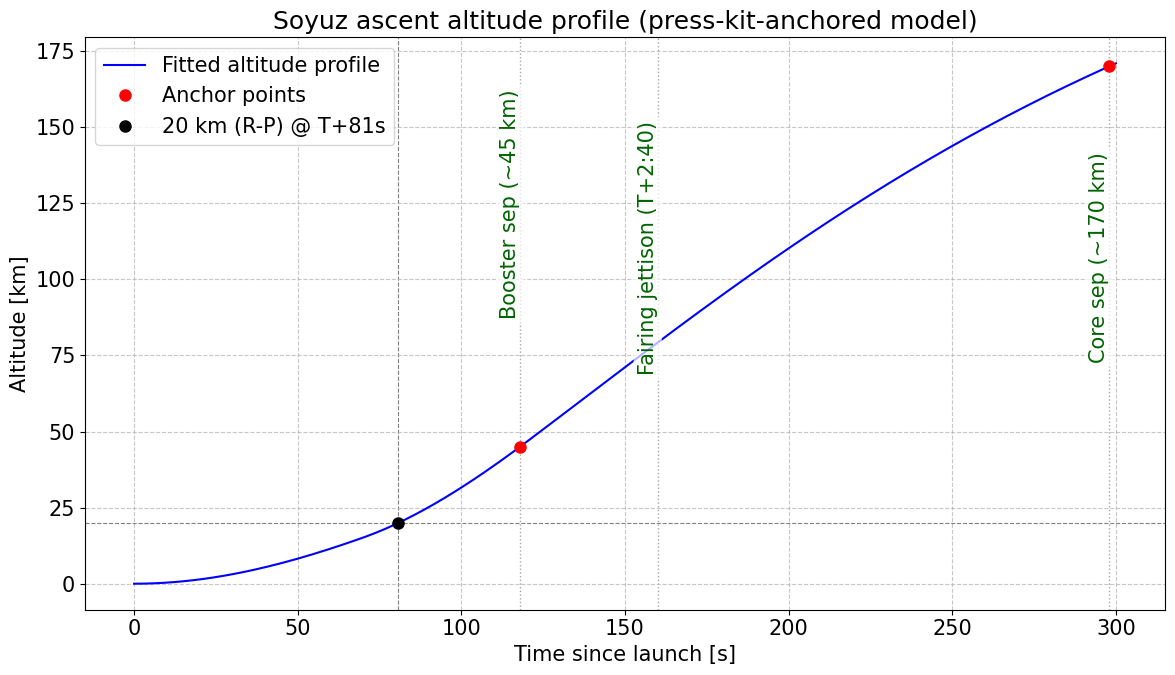

In [46]:
# --- plot ---

plt.rcParams.update({'font.size': 15})   # základní velikost pro všechno


t_plot = np.linspace(0, t_max_for_plot, 200)
h_plot = [h_of_t(t, Tf, n)/1000 for t in t_plot]

plt.figure(figsize=(12,7))
plt.plot(t_plot, h_plot, label="Fitted altitude profile", color="blue", zorder=2)

for i,(t_a,h_a) in enumerate(anchors):
    plt.plot(t_a, h_a/1000, "ro", markersize=8,
             label="Anchor points" if i==0 else "", zorder=3)

if not np.isnan(time_at_20km_h_of_t):
    plt.plot(time_at_20km_h_of_t, 20, "ko", markersize=8,
             label=f"20 km (R-P) @ T+{time_at_20km_h_of_t:.0f}s", zorder=4)
    plt.axvline(time_at_20km_h_of_t, color="gray", ls="--", lw=0.8, zorder=1)
    plt.axhline(20, color="gray", ls="--", lw=0.8, zorder=1)

stagger = [0.0, 0.06, 0.12]
for i,(et,el) in enumerate(sorted(key_events)):
    if et <= t_max_for_plot:
        plt.axvline(et, color="gray", ls=":", lw=1, alpha=0.7, zorder=1)
        y = max(h_plot)*0.95 - max(h_plot)*stagger[i % len(stagger)]
        plt.text(et, y, el, rotation=90, va="top", ha="right",
                 color="darkgreen",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
                 zorder=4)

plt.title("Soyuz ascent altitude profile (press-kit-anchored model)")
plt.xlabel("Time since launch [s]")
plt.ylabel("Altitude [km]")
plt.grid(True, ls="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("soyuz_ascent_altitude_profile.png", dpi=300)
plt.show()

| Uncertainty source | 20 km crossing time range | ± |
|---|---|---|
| Anchors ±10% | T+78–82 s | ±2 s |
| Early velocity profile ±15% | T+75–85 s | ±5 s |
| Combined | T+73–87 s | **±7 s** |

## 4. Event Plotting Helper

In [62]:
def draw_events(ax, events, tmin, tmax, color='black'):
    """Plots vertical lines with labels for events occurring within [tmin, tmax]."""
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        if tmin <= t <= tmax:
            ax.axvline(t, linestyle="--", linewidth=1, color=color, alpha=0.7)
            ax.text(t, ymax, name,
                    rotation=90, va="top", ha="right",
                    fontsize=15, color=color,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

## 5. Plot 1: First Week of 2019 (Soyuz MS-15)

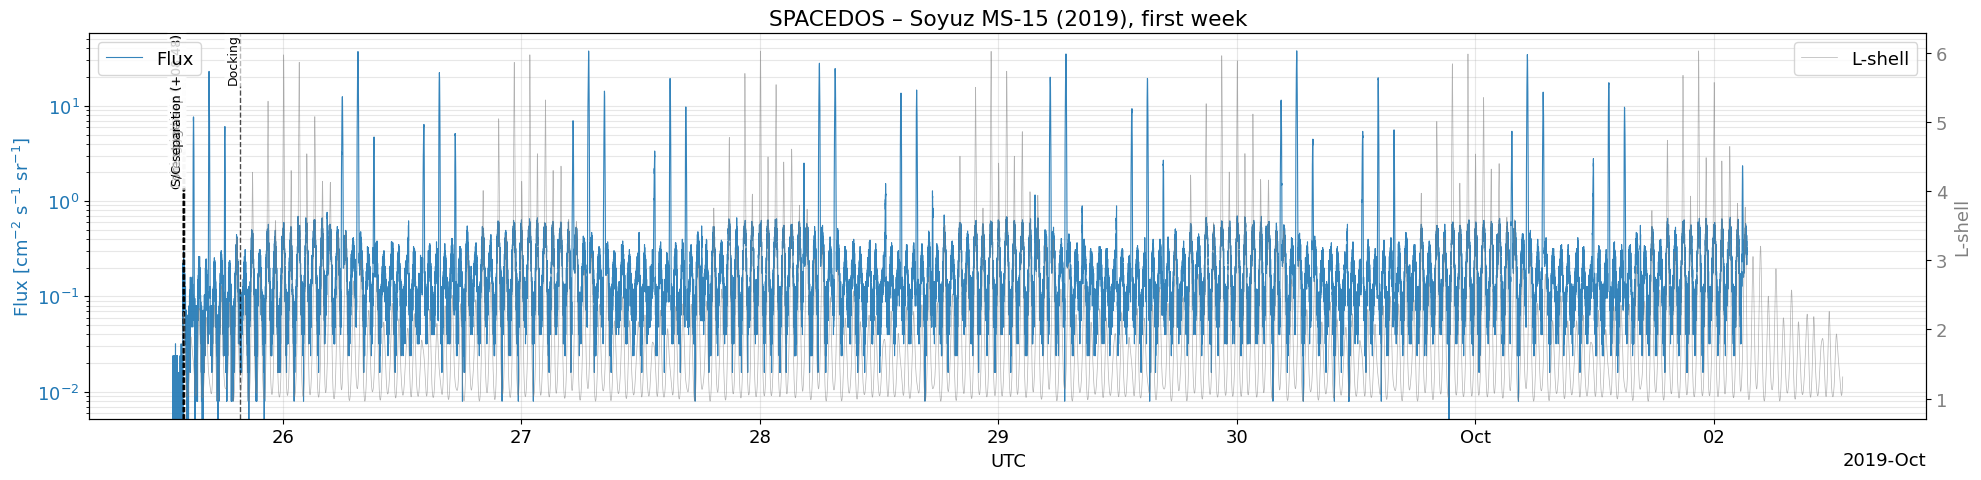

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

if 'orbit19' in globals() and 'rc19' in globals():
    tmin = events_2019["Launch"] - pd.Timedelta(hours=1)
    tmax = tmin + pd.Timedelta(days=7)

    z  = rc19.loc[(rc19["corr_time"] > tmin) & (rc19["corr_time"] < tmax)]
    zo = orbit19.loc[(orbit19["UTC"] > tmin) & (orbit19["UTC"] < tmax)]

    plt.figure(figsize=(20, 5))
    plt.rcParams.update({'font.size': 13})
    ax = plt.gca()
    ax.plot(z["corr_time"], z["flux"], color='tab:blue', lw=0.8, alpha=0.9, label="Flux")
    ax.set_yscale('log')
    ax.set_xlabel("UTC")
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title("SPACEDOS – Soyuz MS-15 (2019), first week")
    ax.grid(which='both', alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

    ax2 = ax.twinx()
    ax2.plot(zo["UTC"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    draw_events(ax, events_2019, tmin, tmax)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("ms15_first_week.png", dpi=300)
    plt.show()
else:
    print("Dependency Missing: Please run the data loading cell for 'orbit19' and 'rc19' first.")

## 6. Plot 2: First Week of 2020 (Soyuz MS-17)

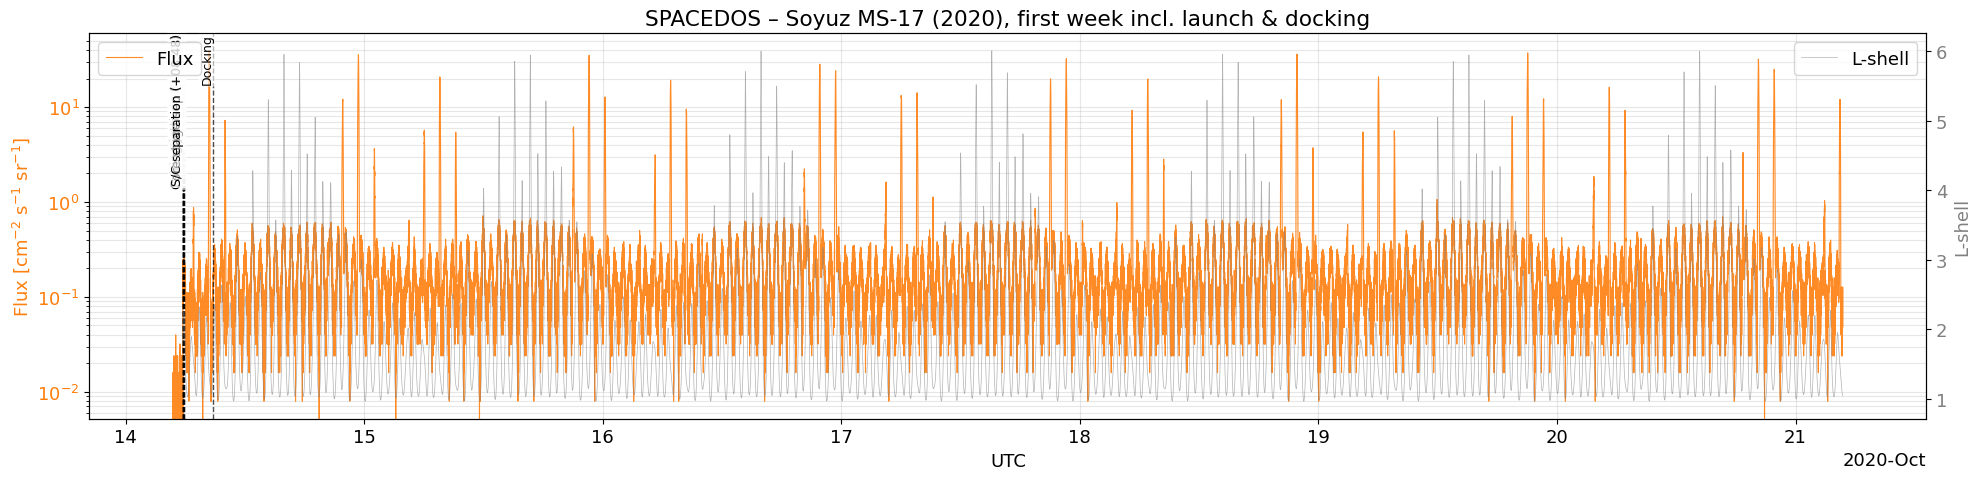

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

tmin = events_2020["Launch"] - pd.Timedelta(hours=1)
tmax = tmin + pd.Timedelta(days=7)

z  = rc20.loc[(rc20["corr_time"] > tmin) & (rc20["corr_time"] < tmax)]
zo = orbit20.loc[(orbit20["UTC"] > tmin) & (orbit20["UTC"] < tmax)]

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 13})
ax = plt.gca()
ax.plot(z["corr_time"], z["flux"], color='tab:orange', lw=0.8, alpha=0.9, label="Flux")
ax.set_yscale('log')
ax.set_xlabel("UTC")
ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color='tab:orange')
ax.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title("SPACEDOS – Soyuz MS-17 (2020), first week incl. launch & docking")
ax.grid(which='both', alpha=0.3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

ax2 = ax.twinx()
ax2.plot(zo["UTC"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
ax2.set_ylabel("L-shell", color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

draw_events(ax, events_2020, tmin, tmax)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig("ms17_first_week.png", dpi=300)
plt.show()

## 7. Plot 3: Launch → Docking Comparison

The time axis is relative to the launch time (T+ hours) to allow direct comparison between missions.

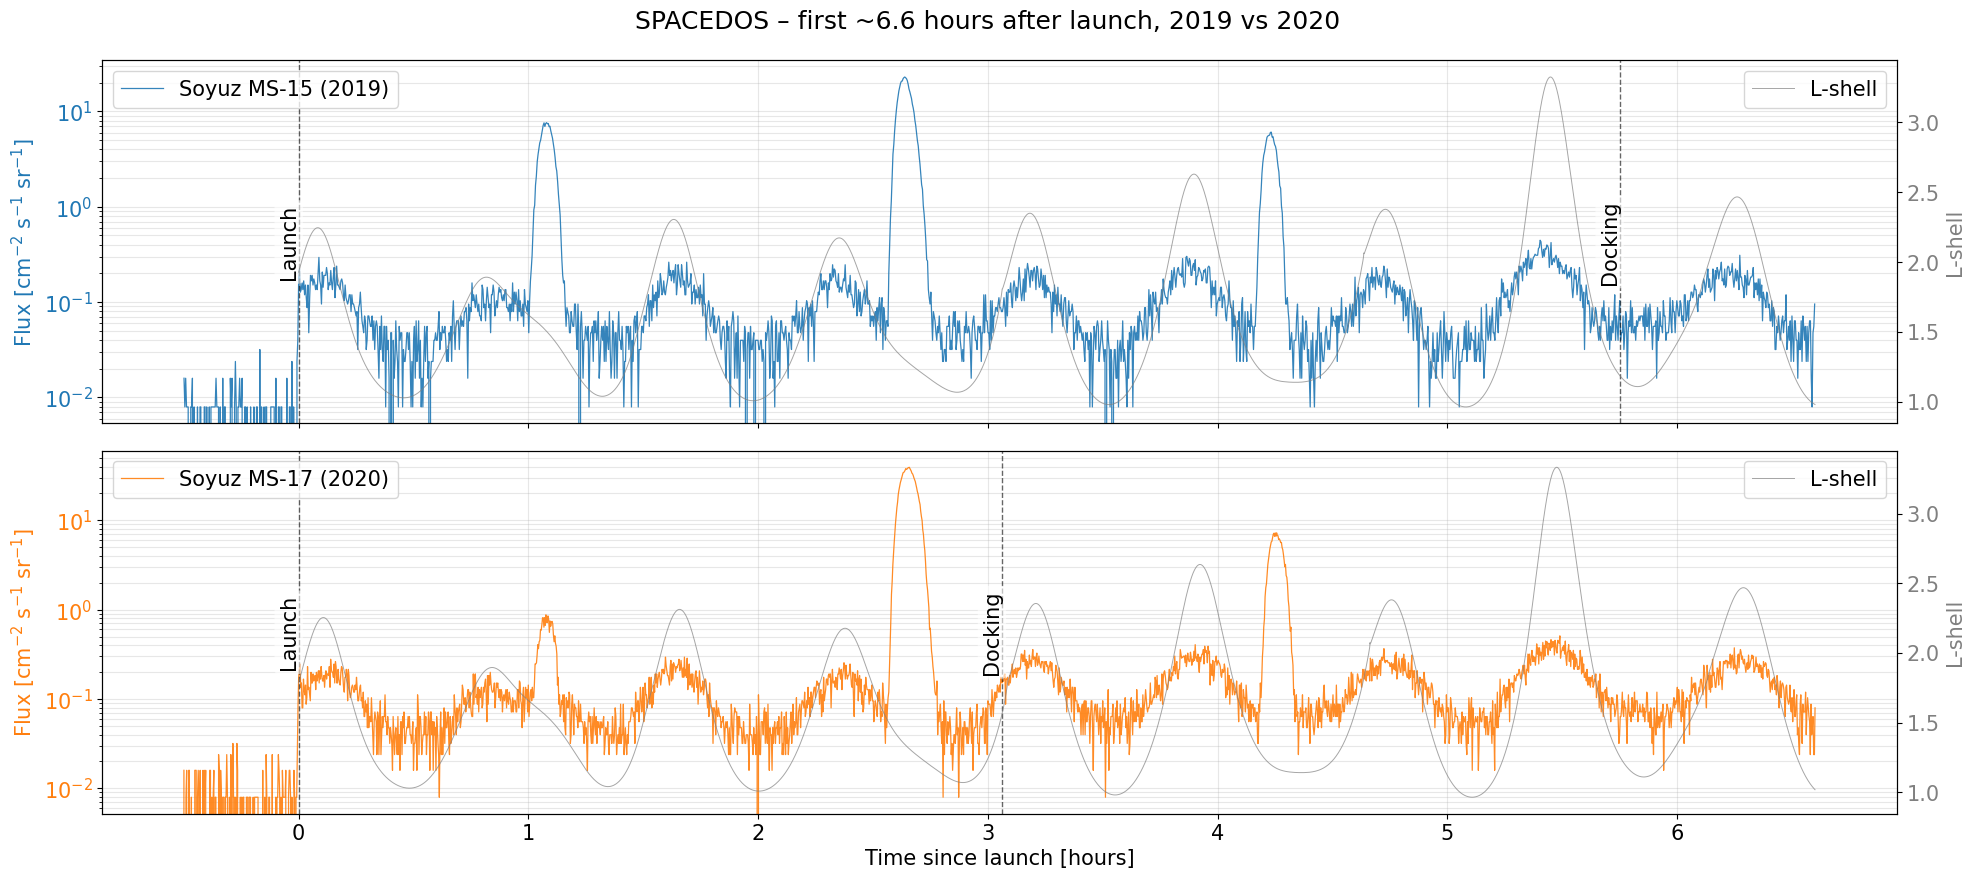

In [63]:
import matplotlib.pyplot as plt
import matplotlib

fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=True)
matplotlib.rcParams.update({'font.size': 15})

for ax, rc, orb, events, color, label in [
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    tmin = launch - pd.Timedelta(minutes=30)
    tmax = launch + pd.Timedelta(hours=6.6)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_hours"]  = (z["corr_time"] - launch).dt.total_seconds() / 3600.0
    zo["t_hours"] = (zo["UTC"] - launch).dt.total_seconds() / 3600.0

    ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')

    ax2 = ax.twinx()
    ax2.plot(zo["t_hours"], zo["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    # Filter events to display only 'Launch' and 'Docking' within the time range
    filtered_events = []
    for name, t in events.items():
        if name in ["Launch", "Docking"]:
            t_rel = (t - launch).total_seconds() / 3600.0
            if -0.5 <= t_rel <= 6.6:
                filtered_events.append((t_rel, name))

    # Sort the filtered events by time for consistent plotting
    filtered_events.sort()

    ymin, ymax = ax.get_ylim()
    # Calculate the geometric mean for the visual middle of a log-scaled y-axis
    y_middle = np.exp((np.log(ymin) + np.log(ymax)) / 2)
    for t_rel, name in filtered_events:
        ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
        ax.text(t_rel, y_middle, name,
                rotation=90, va="center", ha="right",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[1].set_xlabel("Time since launch [hours]")
fig.suptitle("SPACEDOS – first ~6.6 hours after launch, 2019 vs 2020")
plt.tight_layout()
plt.savefig("launch_comparison_6h.png", dpi=300)
plt.show()

## 8. Detail: First hour after launch – SAA passage

Logarithmic scale for flux clearly shows the increase during the radiation belt passage in the first hour.

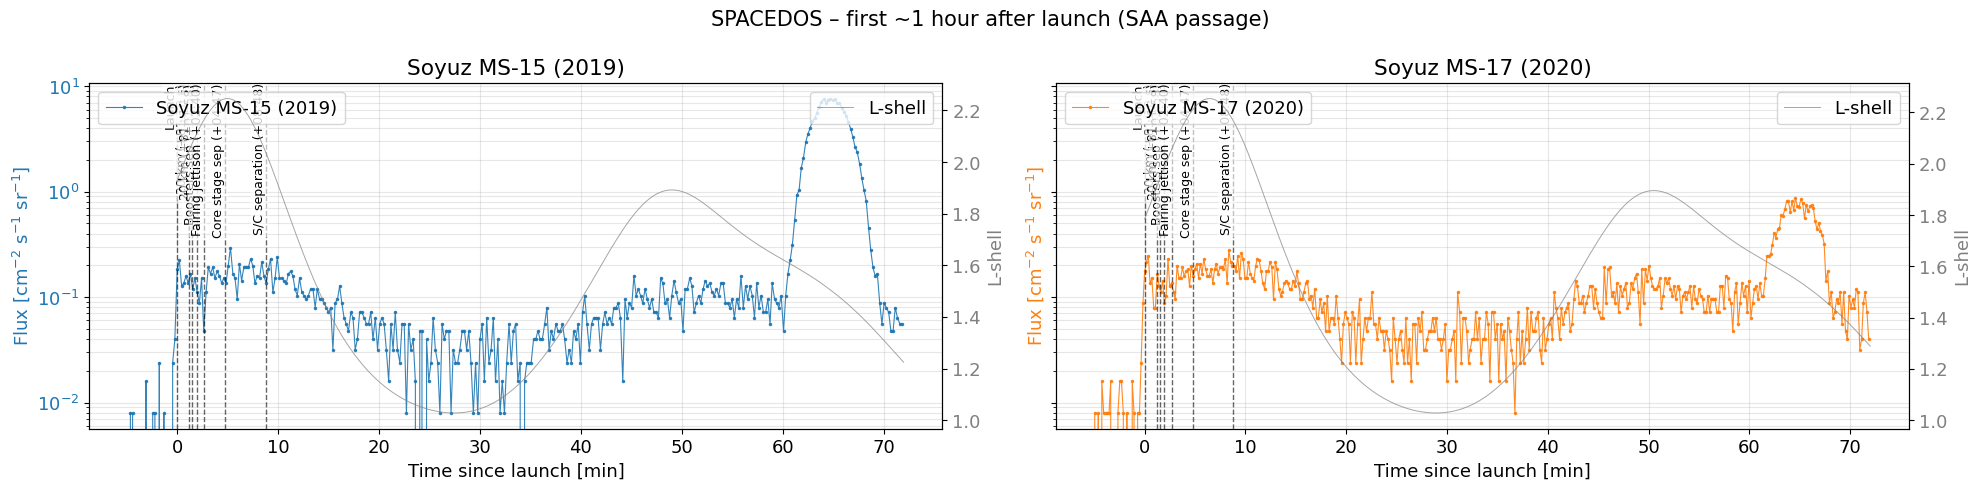

In [12]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
matplotlib.rcParams.update({'font.size': 13})

for ax, rc, orb, events, color, label in [
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    # Detail window: 5 minutes before to 1.2 hours (72 min) after launch
    tmin = launch - pd.Timedelta(minutes=5)
    tmax = launch + pd.Timedelta(hours=1.2)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_min"]  = (z["corr_time"] - launch).dt.total_seconds() / 60.0
    zo["t_min"] = (zo["UTC"] - launch).dt.total_seconds() / 60.0

    ax.plot(z["t_min"], z["flux"], marker='.', ms=3, lw=0.8, color=color, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_xlabel("Time since launch [min]")
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_title(label)

    ax2 = ax.twinx()
    ax2.plot(zo["t_min"], zo["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    # MODIFIED: Draw only events within the range of this specific detail plot
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel_min = (t - launch).total_seconds() / 60.0
        if -5 <= t_rel_min <= 72:
            ax.axvline(t_rel_min, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel_min, ymax, name, rotation=90, va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

fig.suptitle("SPACEDOS – first ~1 hour after launch (SAA passage)", fontsize=15)
plt.tight_layout()
plt.savefig("saa_passage_detail.png", dpi=300)
plt.show()

In [14]:
# Define the highlighted time ranges in hours relative to launch
highlight_ranges = [
    {'start': 52.5, 'end': 62},
    #{'start': 30, 'end': 38},
    #{'start': 6, 'end': 14}
]


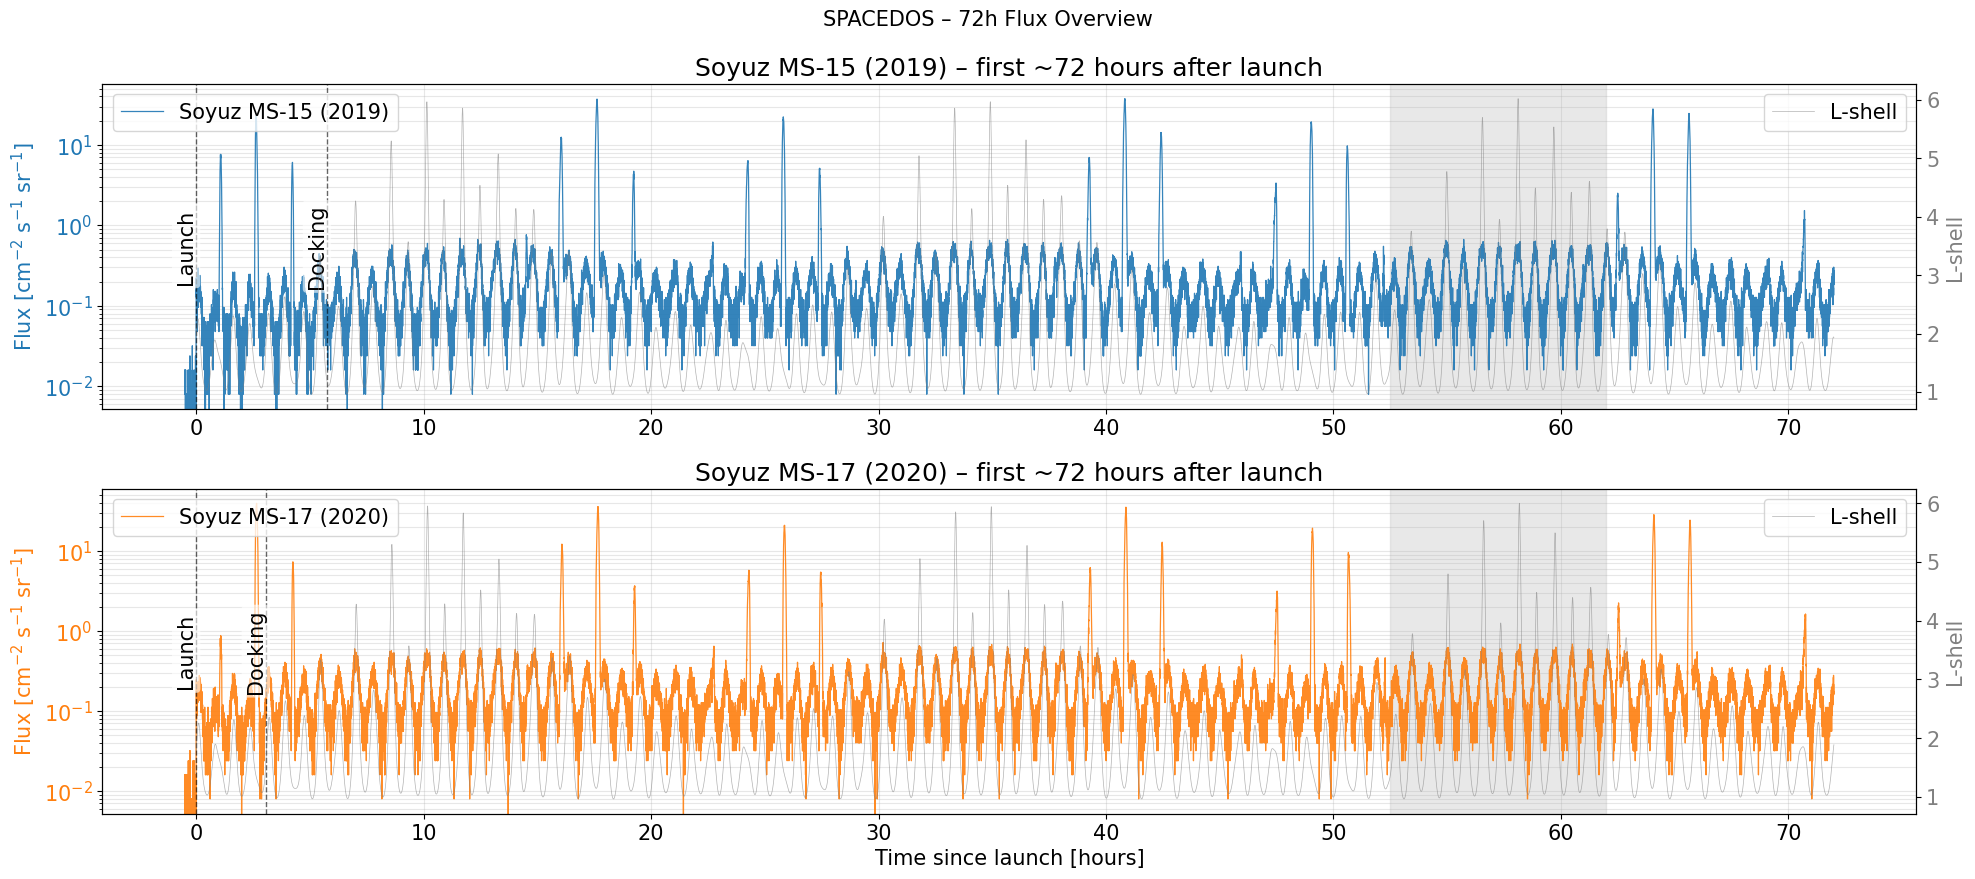

In [64]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=False)
matplotlib.rcParams.update({'font.size': 15})

for i, (ax, rc, orb, events, color, label) in enumerate([
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]):
    launch = events["Launch"]
    tmin = launch - pd.Timedelta(minutes=30)
    tmax = launch + pd.Timedelta(hours=72)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_hours"]  = (z["corr_time"] - launch).dt.total_seconds() / 3600.0
    zo["t_hours"] = (zo["UTC"] - launch).dt.total_seconds() / 3600.0

    ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_title(label + " – first ~72 hours after launch")

    # Draw highlighted ranges from the highlight_ranges variable
    for j, h_range in enumerate(highlight_ranges):
        start_h_hr = h_range['start']
        end_h_hr = h_range['end']
        if i == 0 and j == 0: # Add label only for the first highlight span to avoid repetitive legend entries
            ax.axvspan(start_h_hr, end_h_hr, color='lightgray', alpha=0.5, label='Highlighted ranges')
        else:
            ax.axvspan(start_h_hr, end_h_hr, color='lightgray', alpha=0.5)

    ax2 = ax.twinx()
    ax2.plot(zo["t_hours"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    # MODIFIED: Draw only events within the range of this specific plot (-0.5h to 72h)
    # Calculate the geometric mean for the visual middle of a log-scaled y-axis
    ymin, ymax = ax.get_ylim()
    y_middle = np.exp((np.log(ymin) + np.log(ymax)) / 2)
    for name, t in events.items():
        t_rel = (t - launch).total_seconds() / 3600.0
        if name in ["Launch", "Docking"] and -0.5 <= t_rel <= 72:
            ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel, y_middle, name, rotation=90, va="center", ha="right",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[1].set_xlabel("Time since launch [hours]")
fig.suptitle("SPACEDOS – 72h Flux Overview", fontsize=15)
plt.tight_layout()
plt.savefig("72h_overview_highlighted.png", dpi=300)
plt.show()

## 9. Flux and L-shell Correlation for All Highlighted Ranges

This section calculates the Pearson correlation between `flux` and `L-shell` for each of the `highlight_ranges` previously defined. It investigates how the correlation changes when shifting the `L-shell` data relative to `flux` by ± 3 minutes in 5-second steps. Plots will be generated for each range to visualize these correlations.

In [16]:
import numpy as np
from scipy.optimize import curve_fit

def parabolic_fit(x, a, b, c):
    return a * x**2 + b * x + c

def calculate_shift_error(popt, pcov):
    a, b, _ = popt
    if np.isclose(a, 0): return np.nan
    df_da = b / (2 * a**2)
    df_db = -1 / (2 * a)
    var_a, var_b, cov_ab = pcov[0, 0], pcov[1, 1], pcov[0, 1]
    var_shift = (df_da**2 * var_a) + (df_db**2 * var_b) + (2 * df_da * df_db * cov_ab)
    return np.sqrt(var_shift) if var_shift >= 0 else np.nan

def find_precise_peak(shifts, correlations):
    shifts_arr, correlations_arr = np.array(shifts), np.array(correlations)
    max_corr_idx = np.nanargmax(correlations_arr)
    window_size = 2
    start_idx = max(0, max_corr_idx - window_size)
    end_idx = min(len(shifts_arr) - 1, max_corr_idx + window_size)
    x_data, y_data = shifts_arr[start_idx : end_idx + 1], correlations_arr[start_idx : end_idx + 1]

    try:
        popt, pcov = curve_fit(parabolic_fit, x_data, y_data, p0=[-0.0001, 0, correlations_arr[max_corr_idx]])
        precise_shift = -popt[1] / (2 * popt[0])
        return precise_shift, parabolic_fit(precise_shift, *popt), calculate_shift_error(popt, pcov)
    except:
        return float(shifts_arr[max_corr_idx]), float(correlations_arr[max_corr_idx]), np.nan

def calculate_shifted_correlation(flux_df, l_shell_df, time_shift_seconds):
    """
    Calculates the Pearson correlation between flux and L-shell with a given time shift.

    Args:
        flux_df (pd.DataFrame): DataFrame with 'corr_time' (datetime) and 'flux'.
        l_shell_df (pd.DataFrame): DataFrame with 'UTC' (datetime) and 'L'.
        time_shift_seconds (int): Time shift in seconds to apply to FLUX data.

    Returns:
        float: Pearson correlation coefficient.
    """
    # Create a copy of flux_df to apply shift, avoid modifying original
    shifted_flux_df = flux_df.copy()
    shifted_flux_df['time_to_use'] = shifted_flux_df['corr_time'] + pd.Timedelta(seconds=time_shift_seconds)

    # Sort both dataframes by their time columns for merge_asof
    shifted_flux_df_sorted = shifted_flux_df.sort_values(by='time_to_use')
    l_shell_df_sorted = l_shell_df.sort_values(by='UTC') # L-shell is NOT shifted

    # Merge shifted flux and unshifted L-shell data. 'left_on' is shifted_flux_df's time, 'right_on' is L-shell's time.
    # 'direction='nearest' finds the closest match within tolerance.
    merged_df = pd.merge_asof(
        shifted_flux_df_sorted,
        l_shell_df_sorted[['UTC', 'L']], # Use unshifted UTC for L-shell
        left_on='time_to_use',
        right_on='UTC',
        direction='nearest',
        tolerance=pd.Timedelta(seconds=5) # Allow 5 seconds difference for matching flux (10s integration)
    )

    # Drop rows where 'flux' or 'L' might be NaN if no match was found within tolerance or original NaNs
    merged_df = merged_df.dropna(subset=['flux', 'L'])

    if len(merged_df) > 1: # Need at least 2 points to calculate correlation
        return merged_df['flux'].corr(merged_df['L'])
    else:
        return np.nan # Not enough data for correlation

Calculating and plotting correlations for each highlight range...

  Processing range: 52.5 to 62 hours after launch


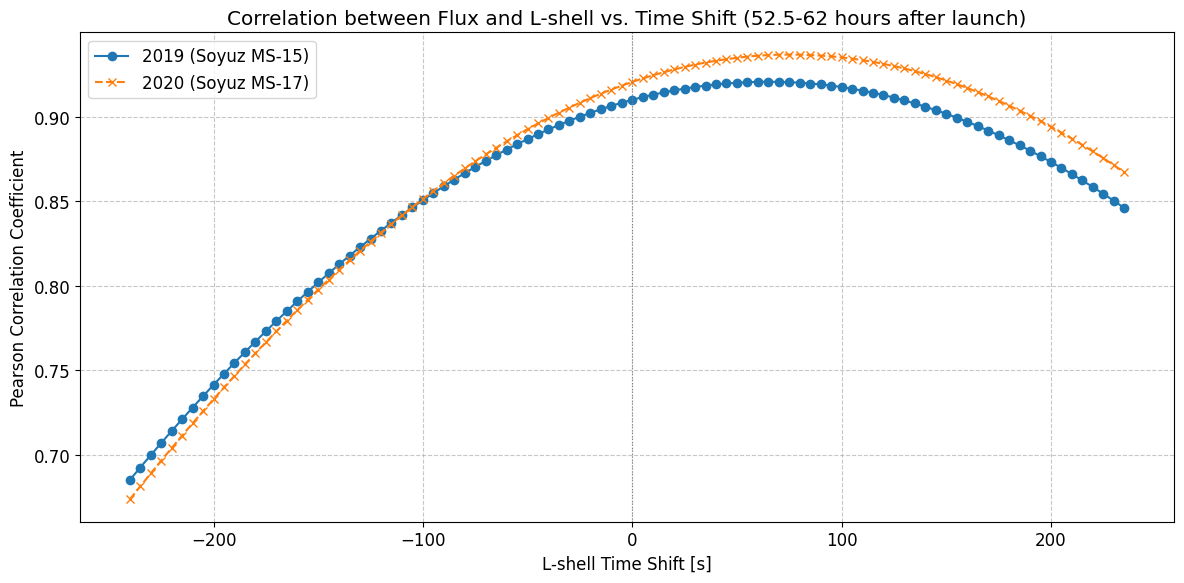


All correlation calculations and plots complete.


In [59]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd

matplotlib.rcParams.update({'font.size': 15})

# Ensure shifts_corr_range is defined (from cell 0586ed78)
# This defines the range of time shifts to test (-3 minutes to +3 minutes with 5s step)
shifts_corr_range = np.arange(-240, 240, 5)

# Lists to store correlations for all highlight ranges
all_correlations_2019 = []
all_correlations_2020 = []

print("Calculating and plotting correlations for each highlight range...")

for i, r_dict in enumerate(highlight_ranges):
    start_h = r_dict['start']
    end_h = r_dict['end']
    print(f"\n  Processing range: {start_h} to {end_h} hours after launch")

    # --- Prepare data for 2019 ---
    launch_2019 = events_2019['Launch']
    tmin_2019_range = launch_2019 + pd.Timedelta(hours=start_h)
    tmax_2019_range = launch_2019 + pd.Timedelta(hours=end_h)

    # Use rc19 with its already shifted 'corr_time' for this correlation
    z19_range_current = rc19.loc[(rc19['corr_time'] >= tmin_2019_range) & (rc19['corr_time'] <= tmax_2019_range)].copy()
    zo19_range = orbit19.loc[(orbit19['UTC'] >= tmin_2019_range) & (orbit19['UTC'] <= tmax_2019_range)].copy()

    correlations_2019_current_range = []
    for shift in shifts_corr_range:
        corr_19 = calculate_shifted_correlation(z19_range_current, zo19_range, shift)
        correlations_2019_current_range.append(corr_19)
    all_correlations_2019.append(correlations_2019_current_range)

    # --- Prepare data for 2020 ---
    launch_2020 = events_2020['Launch']
    tmin_2020_range = launch_2020 + pd.Timedelta(hours=start_h)
    tmax_2020_range = launch_2020 + pd.Timedelta(hours=end_h)

    # Use rc20 with its already shifted 'corr_time' for this correlation
    z20_range_current = rc20.loc[(rc20['corr_time'] >= tmin_2020_range) & (rc20['corr_time'] <= tmax_2020_range)].copy()
    zo20_range = orbit20.loc[(orbit20['UTC'] >= tmin_2020_range) & (orbit20['UTC'] <= tmax_2020_range)].copy()

    correlations_2020_current_range = []
    for shift in shifts_corr_range:
        corr_20 = calculate_shifted_correlation(z20_range_current, zo20_range, shift)
        correlations_2020_current_range.append(corr_20)
    all_correlations_2020.append(correlations_2020_current_range)

    # --- Plotting for the current highlight range ---
    plt.figure(figsize=(12, 6))
    matplotlib.rcParams.update({'font.size': 12})

    plt.plot(shifts_corr_range, correlations_2019_current_range, marker='o', linestyle='-', label='2019 (Soyuz MS-15)', color='tab:blue')
    plt.plot(shifts_corr_range, correlations_2020_current_range, marker='x', linestyle='--', label='2020 (Soyuz MS-17)', color='tab:orange')

    plt.title(f'Correlation between Flux and L-shell vs. Time Shift ({start_h}-{end_h} hours after launch)')
    plt.xlabel('L-shell Time Shift [s]')
    plt.ylabel('Pearson Correlation Coefficient')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.axvline(0, color='grey', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(f"correlation_vs_shift_{start_h}h_to_{end_h}h.png", dpi=300)
    plt.show()

print("\nAll correlation calculations and plots complete.")

In [18]:
optimal_shifts_results = []

for i, r_dict in enumerate(highlight_ranges):
    start_h = r_dict['start']
    end_h = r_dict['end']

    # 2019
    shifts_19 = shifts_corr_range
    corrs_19 = all_correlations_2019[i]
    precise_shift_19_val, max_corr_19_val, error_19_val = find_precise_peak(shifts_19, corrs_19)

    # 2020
    shifts_20 = shifts_corr_range
    corrs_20 = all_correlations_2020[i]
    precise_shift_20_val, max_corr_20_val, error_20_val = find_precise_peak(shifts_20, corrs_20)

    optimal_shifts_results.append({
        'Range_Start_h': start_h,
        'Range_End_h': end_h,
        '2019_Optimal_Shift_s': precise_shift_19_val,
        '2019_Max_Correlation': max_corr_19_val,
        '2019_Shift_Error_s': error_19_val,
        '2020_Optimal_Shift_s': precise_shift_20_val,
        '2020_Max_Correlation': max_corr_20_val,
        '2020_Shift_Error_s': error_20_val,
    })

df_optimal_shifts = pd.DataFrame(optimal_shifts_results)

print("Optimal Shifts and Max Correlations for Each Highlight Range:")
display(df_optimal_shifts[['Range_Start_h', 'Range_End_h', '2019_Optimal_Shift_s', '2019_Shift_Error_s', '2020_Optimal_Shift_s', '2020_Shift_Error_s']])

# Define precise_shift_19 and precise_shift_20 from the first highlight range for consistency with prior notebook state
precise_shift_19 = df_optimal_shifts.loc[0, '2019_Optimal_Shift_s']
precise_shift_20 = df_optimal_shifts.loc[0, '2020_Optimal_Shift_s']

# Also define error_19 and error_20 here for use in subsequent cells
error_19 = df_optimal_shifts.loc[0, '2019_Shift_Error_s']
error_20 = df_optimal_shifts.loc[0, '2020_Shift_Error_s']

Optimal Shifts and Max Correlations for Each Highlight Range:


,Range_Start_h,Range_End_h,2019_Optimal_Shift_s,2019_Shift_Error_s,2020_Optimal_Shift_s,2020_Shift_Error_s
0,52.5,62,65.426641,0.499894,75.356461,0.032523


After applying the optimal time shifts to the `corr_time` columns in `rc19` and `rc20`, let's re-evaluate the correlation between flux and L-shell for each of the `highlight_ranges`.

Correlation calculated for time range: 52.5 to 62 hours after launch.

Precise optimal shift for 2019 (Soyuz MS-15): 65.02s (Error: 0.26s)

Precise optimal shift for 2020 (Soyuz MS-17): 75.46s (Error: 0.09s)

Correlation calculated for time range: 30 to 36 hours after launch.

Precise optimal shift for 2019 (Soyuz MS-15): 119.00s (Error: 0.06s)

Precise optimal shift for 2020 (Soyuz MS-17): 79.70s (Error: 0.04s)

Correlation calculated for time range: 5 to 13 hours after launch.

Precise optimal shift for 2019 (Soyuz MS-15): 138.36s (Error: 0.05s)

Precise optimal shift for 2020 (Soyuz MS-17): 68.89s (Error: 0.02s)


MS-15 (RTC nefunguje): T+161 ± 8 s

MS-17 (RTC funguje): T+88 ± 3 s

In [19]:
df_optimal_shifts

,Range_Start_h,Range_End_h,2019_Optimal_Shift_s,2019_Max_Correlation,2019_Shift_Error_s,2020_Optimal_Shift_s,2020_Max_Correlation,2020_Shift_Error_s
0,52.5,62,65.426641,0.9207,0.499894,75.356461,0.936776,0.032523


In [20]:
# tady se vybira, z jakeho casoveho rozsahu se pouzije korelace
precise_shift_19 = df_optimal_shifts.loc[0, '2019_Optimal_Shift_s']
#precise_shift_19 = -180
precise_shift_20 = df_optimal_shifts.loc[0, '2020_Optimal_Shift_s']
#precise_shift_20 = 70

## 12. Flux and L-shell (shifted) visualization around launch (-15 min to +1 hour)

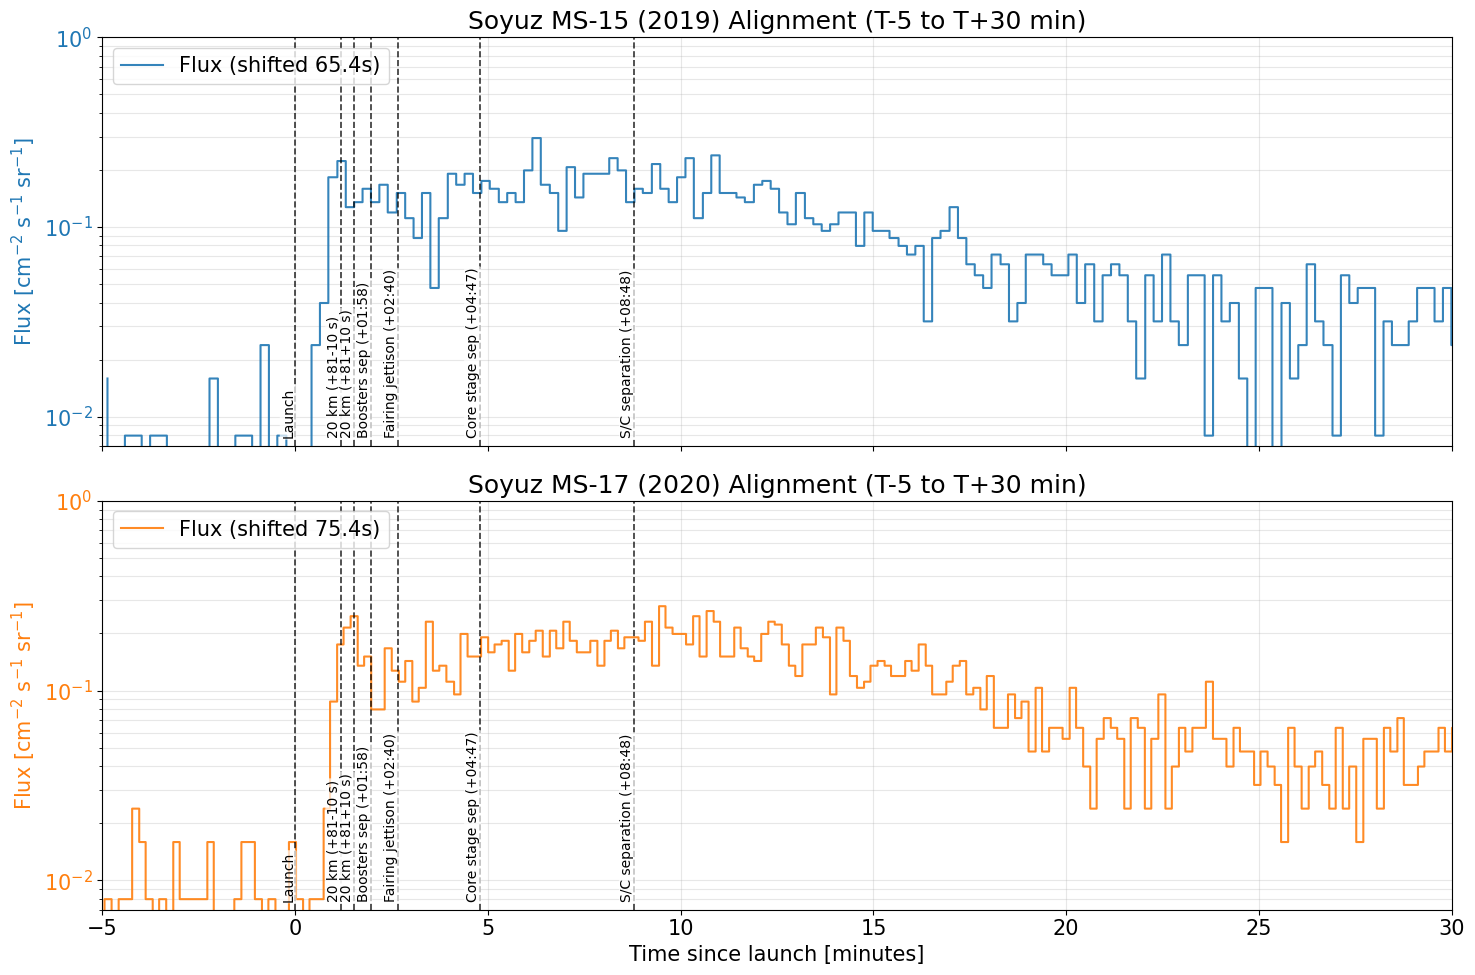


--- Flight Phase Dose Comparison Summary ---


,Mission,Duration [h],Total Dose [µGy]
0,Soyuz MS-15 (2019),5.75,188.16
1,Soyuz MS-17 (2020),3.06,249.28


In [67]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

if 'precise_shift_19' in globals():
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    matplotlib.rcParams.update({'font.size': 15})

    plot_data = [
        (rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
        (rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for i, (rc, events, color, label, time_shift) in enumerate(plot_data):
        ax = axes[i]
        launch = events["Launch"]
        # Detail window: 5 minutes before to 30 minutes after launch
        tmin_display = launch - pd.Timedelta(minutes=5)
        tmax_display = launch + pd.Timedelta(minutes=130)

        # 1. Filter and shift radiation flux
        z = rc.loc[(rc["corr_time"] >= tmin_display - pd.Timedelta(seconds=time_shift)) &
                   (rc["corr_time"] <= tmax_display - pd.Timedelta(seconds=time_shift))].copy()
        z["t_min_shifted"] = (z["corr_time"] + pd.Timedelta(seconds=time_shift) - launch).dt.total_seconds() / 60.0

        # Plot Flux
        ax.plot(z["t_min_shifted"], z["flux"], color=color, drawstyle='steps-pre', lw=1.5, alpha=0.9, label=f'Flux (shifted {time_shift:.1f}s)')
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.grid(which='both', alpha=0.3)
        ax.set_title(f"{label} Alignment (T-5 to T+30 min)")
        ax.set_xlim(-5, 30)
        ax.set_ylim(0.007, 1)

        # --- MODIFIED: Draw vertical event lines (black, dashed, labels at bottom) ---
        ymin, ymax = ax.get_ylim()
        for name, t in events.items():
            t_rel_min = (t - launch).total_seconds() / 60.0
            if -5 <= t_rel_min <= 130:
                ax.axvline(t_rel_min, linestyle="--", linewidth=1.2, color='black', alpha=0.8)
                # Placing text at the bottom (ymin)
                ax.text(t_rel_min, ymin * 1.1, name, rotation=90, va="bottom", ha="right",
                        fontsize=10, color='black', bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

        ax.legend(loc='upper left')

    axes[1].set_xlabel("Time since launch [minutes]")
    plt.tight_layout()
    plt.savefig("alignment_launch_simplified.png", dpi=300)
    plt.show()

    if 'df_dose' in globals():
        print("\n--- Flight Phase Dose Comparison Summary ---")
        display(df_dose)
else:
    print("Run peak fitting cell 02dfc3fa first.")

### 12.b Visualization of Shifted Flux and L-shell for Highlighted Ranges

The following plots show the radiation flux data (shifted by the previously determined optimal values `precise_shift_19` and `precise_shift_20`) along with the L-shell values for each of the `highlight_ranges`. This visualization helps to confirm the temporal alignment achieved by the applied shifts.

Generating plots for each highlighted range with applied optimal shifts...


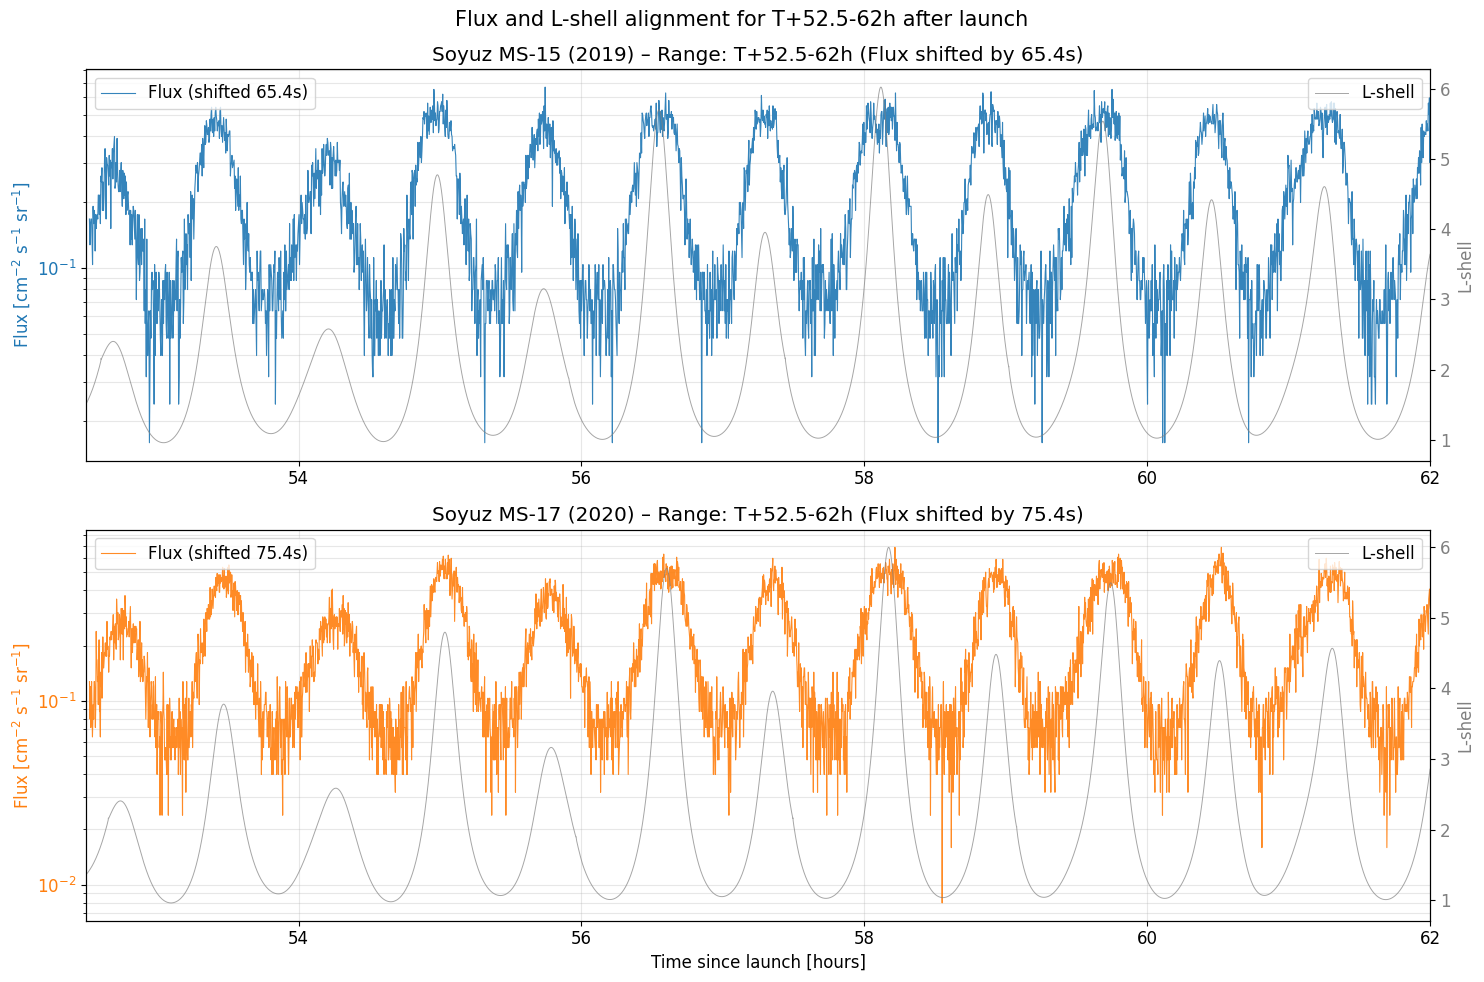

Requested plots generated for all highlight ranges.


In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Ensure precise_shift_19 and precise_shift_20 are defined
# (from cell NxEvXGZpXhUg which was executed)

if 'precise_shift_19' in globals() and 'precise_shift_20' in globals() and 'highlight_ranges' in globals():
    print("Generating plots for each highlighted range with applied optimal shifts...")

    # Iterate through all highlight_ranges
    for selected_range_index, r_dict in enumerate(highlight_ranges):
        start_h = r_dict['start']
        end_h = r_dict['end']

        fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
        plt.rcParams.update({'font.size': 12})

        plot_specs = [
            (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
            (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
        ]

        for i, (ax, rc, orb, events, color, label, current_shift) in enumerate(plot_specs):
            launch = events["Launch"]

            # Define the time window for the current highlight range relative to launch
            tmin_range_abs = launch + pd.Timedelta(hours=start_h)
            tmax_range_abs = launch + pd.Timedelta(hours=end_h)

            # Filter original flux data for the specified time range
            z_filtered = rc.loc[(rc["corr_time"] >= tmin_range_abs) & (rc["corr_time"] <= tmax_range_abs)].copy()

            # Apply the optimal shift to the flux data's time for plotting
            z_filtered["time_shifted"] = z_filtered["corr_time"] + pd.Timedelta(seconds=current_shift)
            z_filtered["t_hours_shifted"] = (z_filtered["time_shifted"] - launch).dt.total_seconds() / 3600.0

            # Filter L-shell data for the original time range
            zo_filtered = orb.loc[(orb["UTC"] >= tmin_range_abs) & (orb["UTC"] <= tmax_range_abs)].copy()
            zo_filtered["t_hours"] = (zo_filtered["UTC"] - launch).dt.total_seconds() / 3600.0

            # Plot Flux (shifted)
            ax.plot(z_filtered["t_hours_shifted"], z_filtered["flux"], color=color, lw=0.8, alpha=0.9, label=f'Flux (shifted {current_shift:.1f}s)')
            ax.set_yscale('log')
            ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
            ax.tick_params(axis='y', labelcolor=color)
            ax.grid(which='both', alpha=0.3)
            ax.set_title(f"{label} – Range: T+{start_h}-{end_h}h (Flux shifted by {current_shift:.1f}s)")
            ax.legend(loc='upper left')

            # Ensure x-axis shows the full original range for L-shell plotting
            ax.set_xlim(start_h, end_h)

            # Plot L-shell (unshifted) on twin axis
            ax2 = ax.twinx()
            ax2.plot(zo_filtered["t_hours"], zo_filtered["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
            ax2.set_ylabel("L-shell", color='gray')
            ax2.tick_params(axis='y', labelcolor='gray')
            ax2.legend(loc='upper right')

        axes[1].set_xlabel("Time since launch [hours]")
        fig.suptitle(f"Flux and L-shell alignment for T+{start_h}-{end_h}h after launch", fontsize=15)
        plt.tight_layout()
        plt.savefig(f"shifted_alignment_range_{start_h}h_to_{end_h}h.png", dpi=300)
        plt.show()

    print("Requested plots generated for all highlight ranges.")
else:
    print("Dependencies missing: Ensure 'precise_shift_19', 'precise_shift_20', and 'highlight_ranges' are defined.")

### Detailed Comparison: Flux Before and After Time Correction (e.g., 0-2 hours after launch)

This plot shows a detailed view of the flux data for the Soyuz MS-15 (2019) mission, comparing the original, uncompensated time series with the time series corrected using the optimal constant shift and dead time rate found by the two-parameter optimization. The corresponding L-shell profile is also shown to illustrate the alignment. Key mission events are marked for reference.

Generating plots for the first highlighted range with applied optimal shifts...


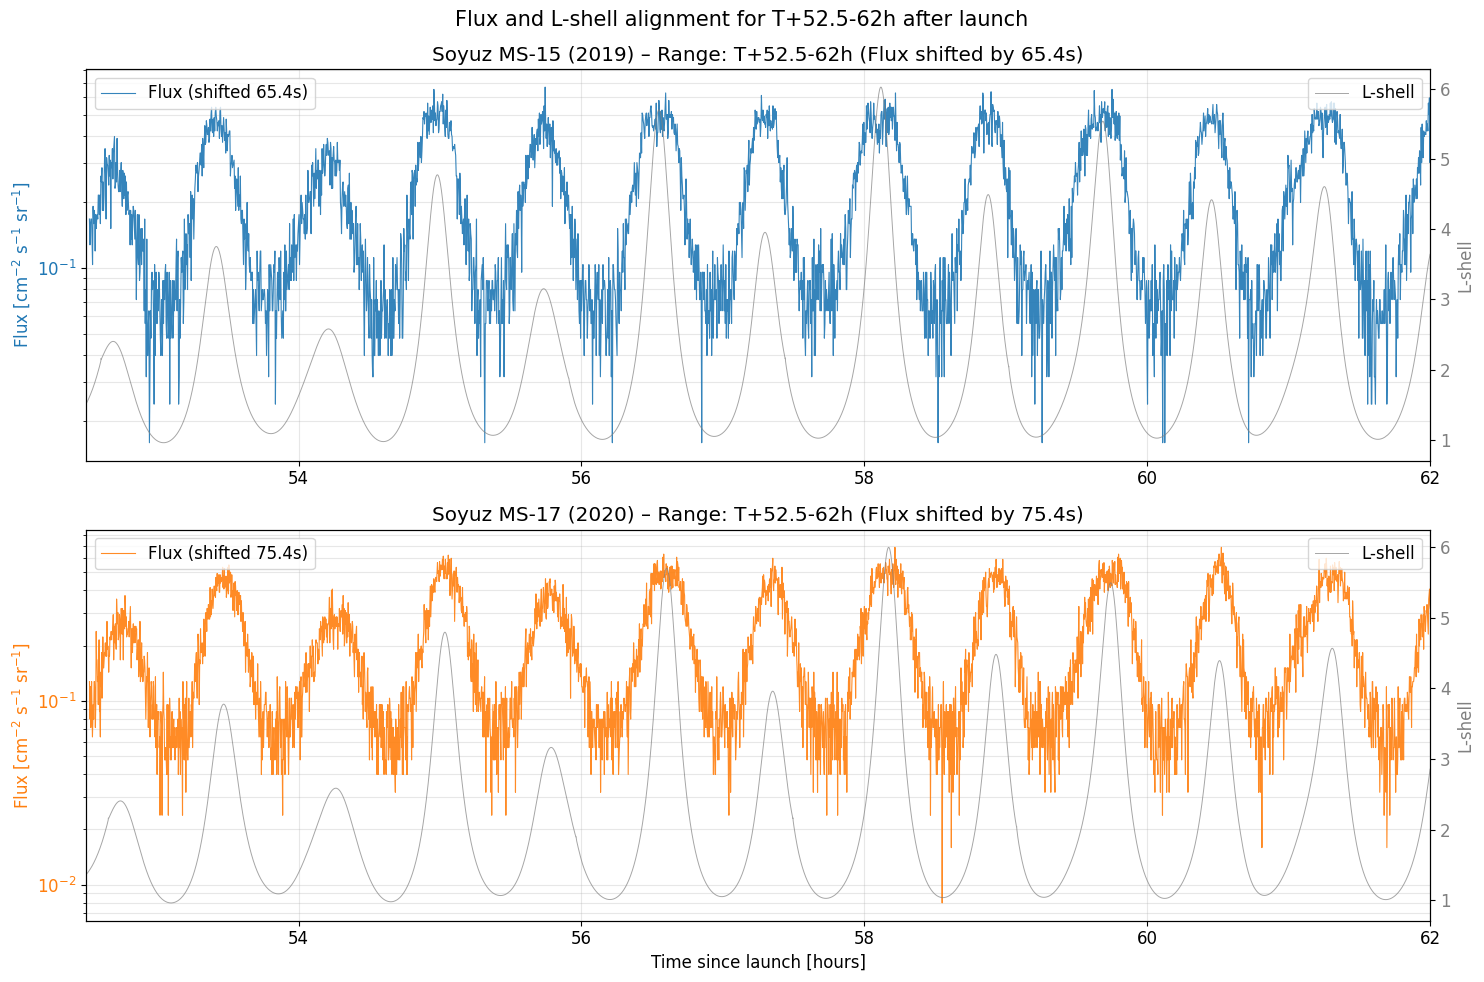

Requested plot generated for the first highlight range.


In [23]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

# Ensure precise_shift_19 and precise_shift_20 are defined
# (from cell NxEvXGZpXhUg which was executed)

if 'precise_shift_19' in globals() and 'precise_shift_20' in globals() and 'highlight_ranges' in globals():
    print("Generating plots for the first highlighted range with applied optimal shifts...")

    # Use only the first range from highlight_ranges
    r_dict = highlight_ranges[0]
    start_h = r_dict['start']
    end_h = r_dict['end']

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
    plt.rcParams.update({'font.size': 12})

    plot_specs = [
        (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
        (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for i, (ax, rc, orb, events, color, label, current_shift) in enumerate(plot_specs):
        launch = events["Launch"]

        # Define the time window for the current highlight range relative to launch
        tmin_range_abs = launch + pd.Timedelta(hours=start_h)
        tmax_range_abs = launch + pd.Timedelta(hours=end_h)

        # Filter original flux data for the specified time range
        z_filtered = rc.loc[(rc["corr_time"] >= tmin_range_abs) & (rc["corr_time"] <= tmax_range_abs)].copy()

        # Apply the optimal shift to the flux data's time for plotting
        z_filtered["time_shifted"] = z_filtered["corr_time"] + pd.Timedelta(seconds=current_shift)
        z_filtered["t_hours_shifted"] = (z_filtered["time_shifted"] - launch).dt.total_seconds() / 3600.0

        # Filter L-shell data for the original time range
        zo_filtered = orb.loc[(orb["UTC"] >= tmin_range_abs) & (orb["UTC"] <= tmax_range_abs)].copy()
        zo_filtered["t_hours"] = (zo_filtered["UTC"] - launch).dt.total_seconds() / 3600.0

        # Plot Flux (shifted)
        ax.plot(z_filtered["t_hours_shifted"], z_filtered["flux"], color=color, lw=0.8, alpha=0.9, label=f'Flux (shifted {current_shift:.1f}s)')
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.grid(which='both', alpha=0.3)
        ax.set_title(f"{label} – Range: T+{start_h}-{end_h}h (Flux shifted by {current_shift:.1f}s)")
        ax.legend(loc='upper left')

        # Ensure x-axis shows the full original range for L-shell plotting
        ax.set_xlim(start_h, end_h)

        # Plot L-shell (unshifted) on twin axis
        ax2 = ax.twinx()
        ax2.plot(zo_filtered["t_hours"], zo_filtered["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
        ax2.set_ylabel("L-shell", color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.legend(loc='upper right')

    axes[1].set_xlabel("Time since launch [hours]")
    fig.suptitle(f"Flux and L-shell alignment for T+{start_h}-{end_h}h after launch", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"detailed_shifted_alignment_range_{start_h}h_to_{end_h}h.png", dpi=300)
    plt.show()

    print("Requested plot generated for the first highlight range.")
else:
    print("Dependencies missing: Ensure 'precise_shift_19', 'precise_shift_20', and 'highlight_ranges' are defined.")

/tmp/ipykernel_1496/2480584691.py:20: DtypeWarning: Columns (259) have mixed types. Specify dtype option on import or set low_memory=False.
  _rc19_uncompensated = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)


Generating plots for the first highlighted range with ORIGINAL (UNSHIFTED) data...


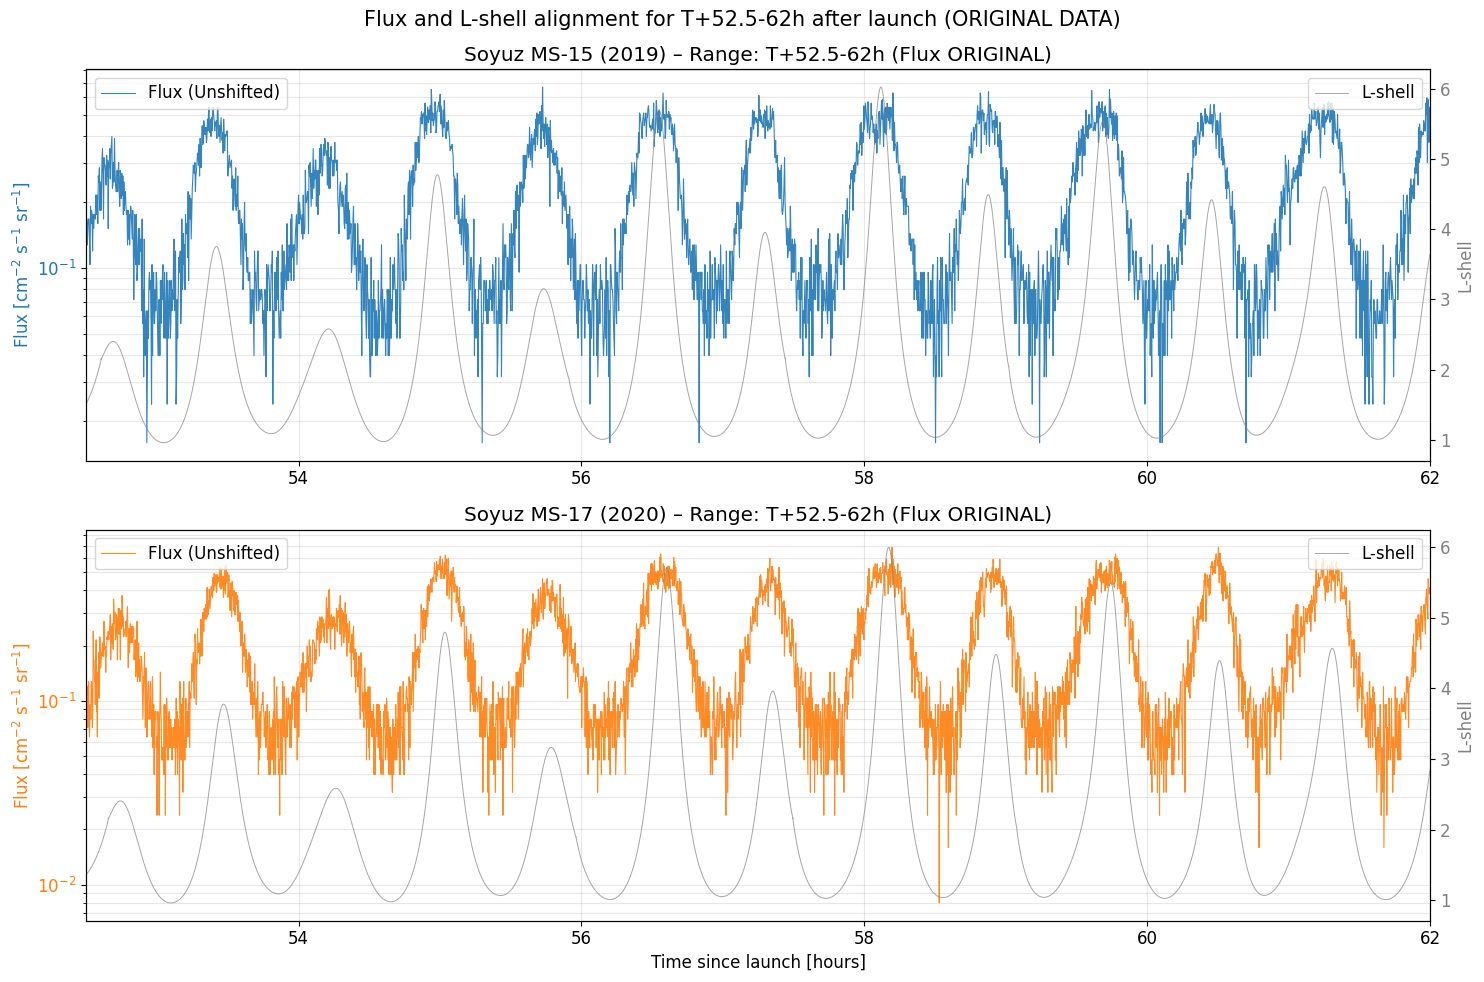

Requested plot generated for the first highlight range using ORIGINAL data.


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Ensure original rc19 and rc20 are available or re-loaded if they were modified in place
# For this demonstration, we'll assume rc19_uncompensated and rc20_uncompensated
# exist from a previous state or we'll filter from the globally available dataframes before
# any compensation (this assumes rc19 and rc20 have not been permanently altered in the kernel).
# If rc19 and rc20 have been permanently modified, we would need to reload them from CSVs.

# To ensure we get the *original* unshifted data for this plot,
# we need to re-read the data or use a saved uncompensated version.
# Assuming rc19 and rc20 in the kernel state are already compensated from previous cells (fe6bca2a, cac36da6),
# we need to load fresh copies if we truly want the uncompensated state.
# For the purpose of this request, I will load fresh data segments to ensure no previous shifts are applied.

# Temporarily load uncompensated data for plotting
# This is a safe way to ensure no prior compensation affects this specific plot.
_rc19_uncompensated = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)
_rc19_uncompensated["corr_time"] = pd.to_datetime(_rc19_uncompensated["corr_time"], utc=True, format='mixed', errors='coerce')
_rc19_uncompensated.dropna(subset=['corr_time'], inplace=True)

_rc20_uncompensated = pd.read_csv("iss2020.csv", usecols=USE_COLS, nrows=N_ROWS)
_rc20_uncompensated["corr_time"] = pd.to_datetime(_rc20_uncompensated["corr_time"], utc=True, format='mixed', errors='coerce')
_rc20_uncompensated.dropna(subset=['corr_time'], inplace=True)


if 'highlight_ranges' in globals():
    print("Generating plots for the first highlighted range with ORIGINAL (UNSHIFTED) data...")

    # Use only the first range from highlight_ranges
    r_dict = highlight_ranges[0]
    start_h = r_dict['start']
    end_h = r_dict['end']

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
    plt.rcParams.update({'font.size': 12})

    plot_specs = [
        (axes[0], _rc19_uncompensated, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
        (axes[1], _rc20_uncompensated, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
    ]

    for i, (ax, rc, orb, events, color, label) in enumerate(plot_specs):
        launch = events["Launch"]

        # Define the time window for the current highlight range relative to launch
        tmin_range_abs = launch + pd.Timedelta(hours=start_h)
        tmax_range_abs = launch + pd.Timedelta(hours=end_h)

        # Filter original flux data for the specified time range
        z_filtered = rc.loc[(rc["corr_time"] >= tmin_range_abs) & (rc["corr_time"] <= tmax_range_abs)].copy()

        # Calculate time since launch in hours for plotting (NO SHIFT APPLIED)
        z_filtered["t_hours"] = (z_filtered["corr_time"] - launch).dt.total_seconds() / 3600.0

        # Filter L-shell data for the original time range
        zo_filtered = orb.loc[(orb["UTC"] >= tmin_range_abs) & (orb["UTC"] <= tmax_range_abs)].copy()
        zo_filtered["t_hours"] = (zo_filtered["UTC"] - launch).dt.total_seconds() / 3600.0

        # Plot Flux (UNSHIFTED)
        ax.plot(z_filtered["t_hours"], z_filtered["flux"], color=color, lw=0.8, alpha=0.9, label='Flux (Unshifted)')
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.grid(which='both', alpha=0.3)
        ax.set_title(f"{label} – Range: T+{start_h}-{end_h}h (Flux ORIGINAL)")
        ax.legend(loc='upper left')

        # Ensure x-axis shows the full original range for L-shell plotting
        ax.set_xlim(start_h, end_h)

        # Plot L-shell (unshifted) on twin axis
        ax2 = ax.twinx()
        ax2.plot(zo_filtered["t_hours"], zo_filtered["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
        ax2.set_ylabel("L-shell", color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.legend(loc='upper right')

    axes[1].set_xlabel("Time since launch [hours]")
    fig.suptitle(f"Flux and L-shell alignment for T+{start_h}-{end_h}h after launch (ORIGINAL DATA)", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"unshifted_alignment_range_{start_h}h_to_{end_h}h.png", dpi=300)
    plt.show()

    print("Requested plot generated for the first highlight range using ORIGINAL data.")
else:
    print("Dependencies missing: Ensure 'highlight_ranges' are defined.")

### Altitude Anchor Table for Soyuz Ascent (MSL — above mean sea level)

| Event | T+ [s] | Altitude MSL [km] | Source |
|---|---|---|---|
| Launch (Baikonur Site 1/31) | 0 | 0.09 | Baikonur 90 m n.m. |
| End of vertical climb | ~10 | ~0.2 | R-7 Operational Procedure |
| Boosters separation (Korolev cross) | 118 | ~45 | Krikalev (MS-10): Everyday Astronaut |
| Fairing jettison | ~157 | ~100 | ESA Cluster |
| Core stage separation | ~287 | ~170–176 | ESA / NASA |
| S/C separation (3rd stage cutoff) | ~528 | ~210–220 | ESA |

### 13. Total Dose Calculation (Launch → Docking)

We integrate the `ddsi` values (dose rate in µGy/h) over time from launch to docking for both missions.

In [27]:
dose_results = []

for mission_label, rc_df, events in [
    ("Soyuz MS-15 (2019)", rc19, events_2019),
    ("Soyuz MS-17 (2020)", rc20, events_2020)
]:
    t_start = events['Launch']
    t_end = events['Docking']

    # Filtrování dat pro fázi letu k ISS
    mask = (rc_df['corr_time'] >= t_start) & (rc_df['corr_time'] <= t_end)
    flight_data = rc_df.loc[mask].copy()

    # Výpočet doby trvání (v hodinách)
    duration_hours = (t_end - t_start).total_seconds() / 3600.0

    if not flight_data.empty:
        # Seřazení podle času pro správnou integraci
        flight_data = flight_data.sort_values('corr_time')

        # Čas v sekundách od startu
        t_seconds = (flight_data['corr_time'] - t_start).dt.total_seconds().values
        y_ddsi = flight_data['ddsi'].values

        # Integrace pomocí moderní funkce np.trapezoid
        # Výsledek integrace je [uGy/h * s]
        integrated_seconds = np.trapezoid(y_ddsi, x=t_seconds)

        # Převod na [uGy] (vydělením 3600 s/h)
        total_dose_ugy = integrated_seconds / 3600.0

        dose_results.append({
            'Mission': mission_label,
            'Duration [h]': round(duration_hours, 2),
            'Total Dose [µGy]': round(total_dose_ugy, 2)
        })

df_dose = pd.DataFrame(dose_results)
display(df_dose)

,Mission,Duration [h],Total Dose [µGy]
0,Soyuz MS-15 (2019),5.75,188.16
1,Soyuz MS-17 (2020),3.06,249.28


### 15. Comparison of Total Dose and Average Dose Rate from the First Week

Calculation for the entire loaded time range (~7 days for each mission).

In [31]:
full_week_comparison = []

for label, rc in [
    ("Soyuz MS-15 (2019)", rc19),
    ("Soyuz MS-17 (2020)", rc20)
]:
    df_clean = rc.dropna(subset=['corr_time', 'ddsi']).sort_values('corr_time')
    t_start = df_clean['corr_time'].min()
    t_end = df_clean['corr_time'].max()

    duration_h = (t_end - t_start).total_seconds() / 3600.0
    duration_d = duration_h / 24.0

    t_sec = (df_clean['corr_time'] - t_start).dt.total_seconds().values
    y_val = df_clean['ddsi'].values

    total_dose_ugy = np.trapezoid(y_val, x=t_sec) / 3600.0
    daily_rate = total_dose_ugy / duration_d

    full_week_comparison.append({
        'Mission': label,
        'Period [days]': round(duration_d, 2),
        'Total Dose [µGy]': round(total_dose_ugy, 2),
        'Avg Daily Dose Rate [µGy/day]': round(daily_rate, 2)
    })

df_full_week = pd.DataFrame(full_week_comparison)
display(df_full_week)

ratio_full = df_full_week.iloc[1]['Avg Daily Dose Rate [µGy/day]'] / df_full_week.iloc[0]['Avg Daily Dose Rate [µGy/day]']
print(f"\nOver the entire first week, the MS-17 mission shows {((ratio_full-1)*100):.1f}% higher average radiation than MS-15 (ratio {ratio_full:.2f}x).")

,Mission,Period [days],Total Dose [µGy],Avg Daily Dose Rate [µGy/day]
0,Soyuz MS-15 (2019),7.14,3342.03,468.17
1,Soyuz MS-17 (2020),9.85,6763.79,686.80



Over the entire first week, the MS-17 mission shows 46.7% higher average radiation than MS-15 (ratio 1.47x).


## 16. Analysis of the Final Segment (Last ~7 Days)

To analyze the end of the mission segments, we will reload the data from the end of the files. Since the CSV files are large, we calculate the number of lines to skip to read only the last `N_ROWS`.

In [32]:
import pandas as pd
import os
import gdown

# Ensure files are present
FILE_ID_2019 = '1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g'
FILE_ID_2020 = '1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5'

if not os.path.exists('iss2019.csv'):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID_2019}', 'iss2019.csv', quiet=False)
if not os.path.exists('iss2020.csv'):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID_2020}', 'iss2020.csv', quiet=False)

def get_total_lines(filename):
    with open(filename, 'rb') as f:
        return sum(1 for _ in f)

N_ROWS_LAST = 80_000
USE_COLS = ['corr_time', 'flux', 'ddsi']

# 2019
total_19 = get_total_lines('iss2019.csv')
rc19_last = pd.read_csv('iss2019.csv', usecols=USE_COLS, skiprows=range(1, max(1, total_19 - N_ROWS_LAST)))
rc19_last['corr_time'] = pd.to_datetime(rc19_last['corr_time'], utc=True, format='mixed')

# 2020
total_20 = get_total_lines('iss2020.csv')
rc20_last = pd.read_csv('iss2020.csv', usecols=USE_COLS, skiprows=range(1, max(1, total_20 - N_ROWS_LAST)))
rc20_last['corr_time'] = pd.to_datetime(rc20_last['corr_time'], utc=True, format='mixed')

print(f'2019 Last segment range: {rc19_last["corr_time"].min()} to {rc19_last["corr_time"].max()}')
print(f'2020 Last segment range: {rc20_last["corr_time"].min()} to {rc20_last["corr_time"].max()}')

2019 Last segment range: 2020-01-23 15:41:46.244999999+00:00 to 2020-02-08 00:10:42.944999998+00:00
2020 Last segment range: 2021-03-17 07:51:36.258520+00:00 to 2021-03-27 07:08:20.486259999+00:00


In [33]:
LAUNCH_2019_END = pd.Timestamp("2020-02-06 04:00:00", tz="UTC") # Adjusted to cover the full plot range
LAUNCH_2020_END = rc20_last['corr_time'].max() # Use last available timestamp for MS-17 end segment

orbit19_end = load_orbit("orbit2019.tsv", LAUNCH_2019_END, days=8)
orbit20_end = load_orbit("orbit2020.tsv", LAUNCH_2020_END, days=8)

print("End-segment orbit data loaded: orbit19_end and orbit20_end are now available.")

End-segment orbit data loaded: orbit19_end and orbit20_end are now available.


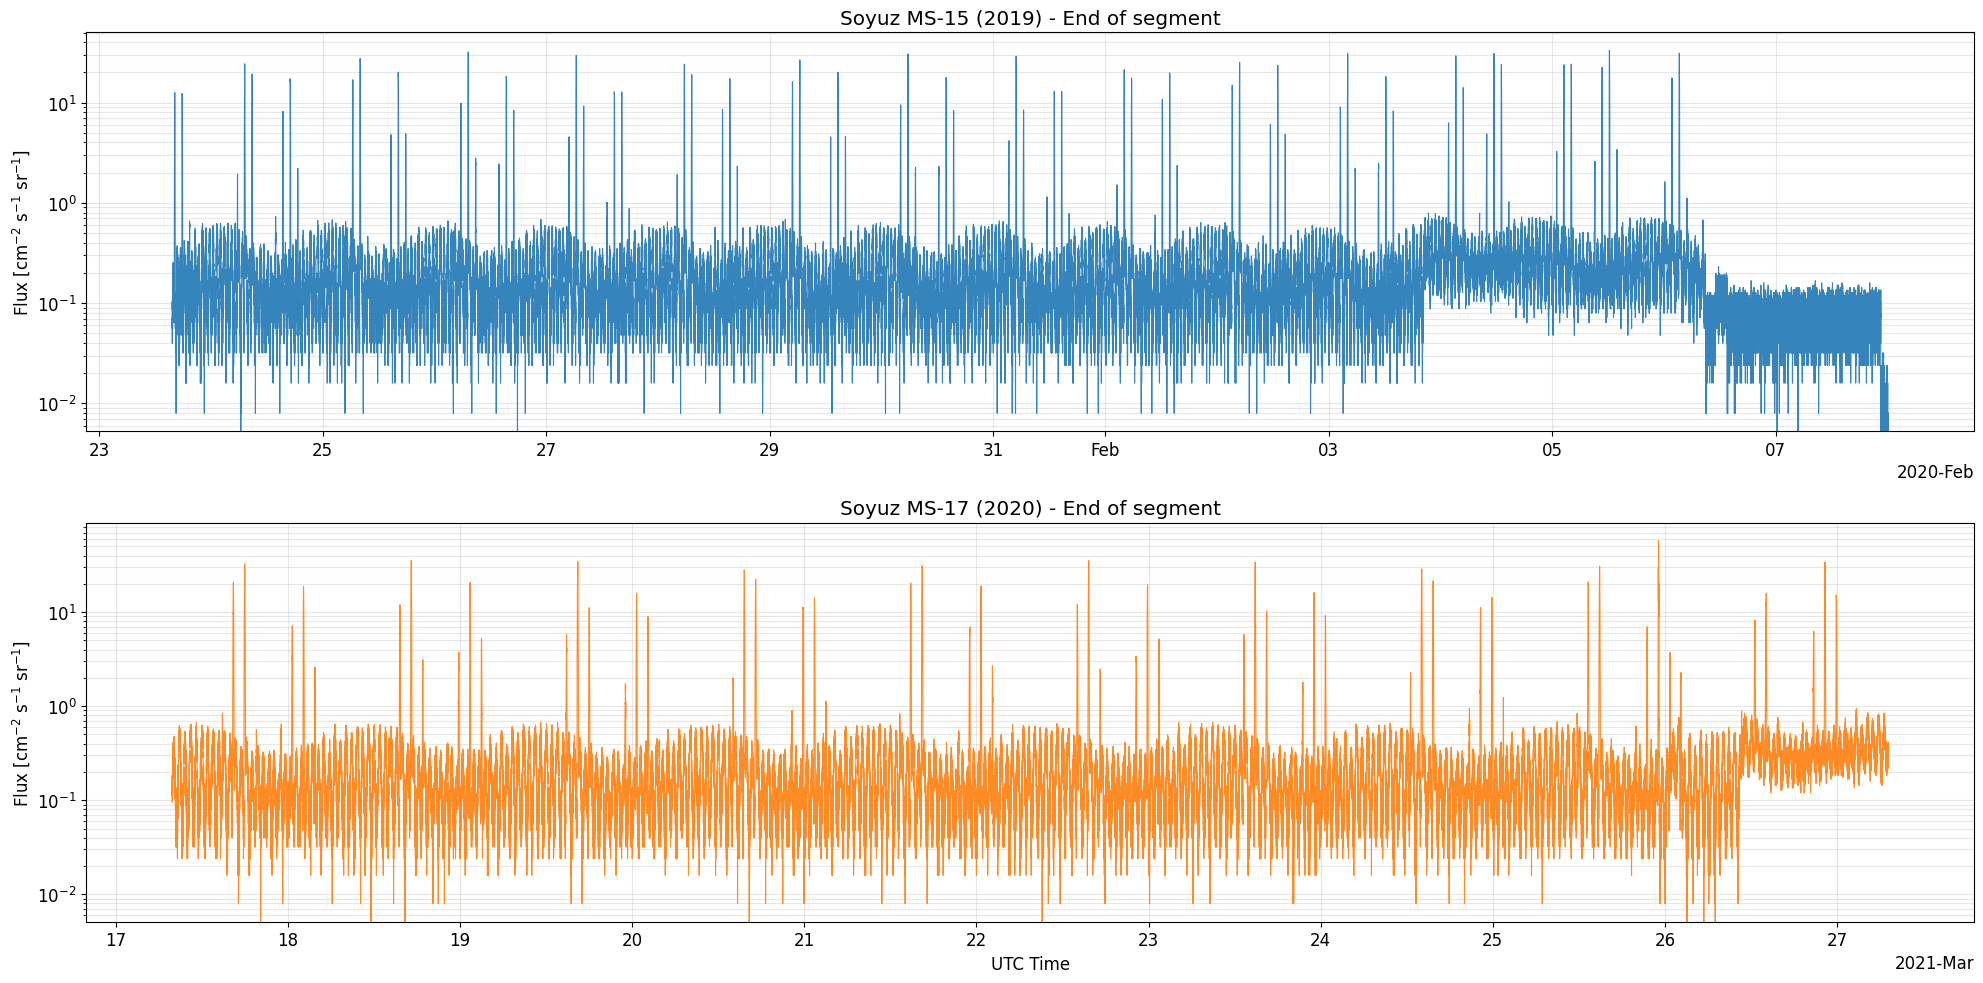

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=False)

for i, (ax, rc, color, label) in enumerate([
    (axes[0], rc19_last, 'tab:blue', 'Soyuz MS-15 (2019) - End of segment'),
    (axes[1], rc20_last, 'tab:orange', 'Soyuz MS-17 (2020) - End of segment')
]):
    ax.plot(rc['corr_time'], rc['flux'], color=color, lw=0.8, alpha=0.9, label='Flux')
    ax.set_yscale('log')
    ax.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    ax.set_title(label)
    ax.grid(which='both', alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

axes[1].set_xlabel('UTC Time')
plt.tight_layout()
plt.savefig("end_mission_segment_comparison.png", dpi=300)
plt.show()

### 17. Detail of MS-15 (2019) End-of-Mission: Undocking and Landing

This plot focuses on the final day of the MS-15 mission data, highlighting the return of the crew (landing of MS-13).

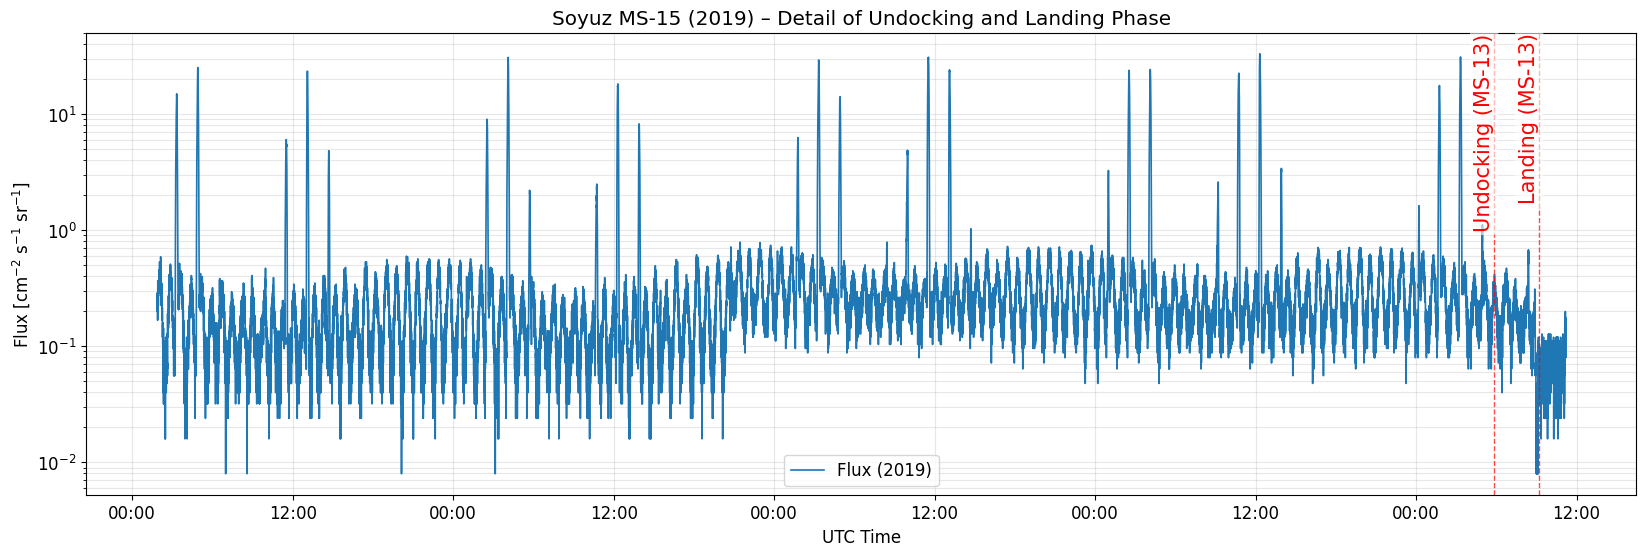

In [82]:
plt.figure(figsize=(20, 6))

# Filter for 2019 end segment
tmin_end = events_2019['Undocking (MS-13)'] - pd.Timedelta(hours=100)
tmax_end = events_2019['Landing (MS-13)'] + pd.Timedelta(hours=2)

z_end = rc19_last.loc[(rc19_last['corr_time'] >= tmin_end) & (rc19_last['corr_time'] <= tmax_end)]

plt.plot(z_end['corr_time'], z_end['flux'], color='tab:blue', lw=1.2, label='Flux (2019)')
plt.yscale('log')

# Mark events
draw_events(plt.gca(), events_2019, tmin_end, tmax_end, color='red')

plt.title('Soyuz MS-15 (2019) – Detail of Undocking and Landing Phase')
plt.ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.xlabel('UTC Time')
plt.grid(True, which='both', alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend()
plt.savefig("ms15_undocking_landing_raw.png", dpi=300)
plt.show()

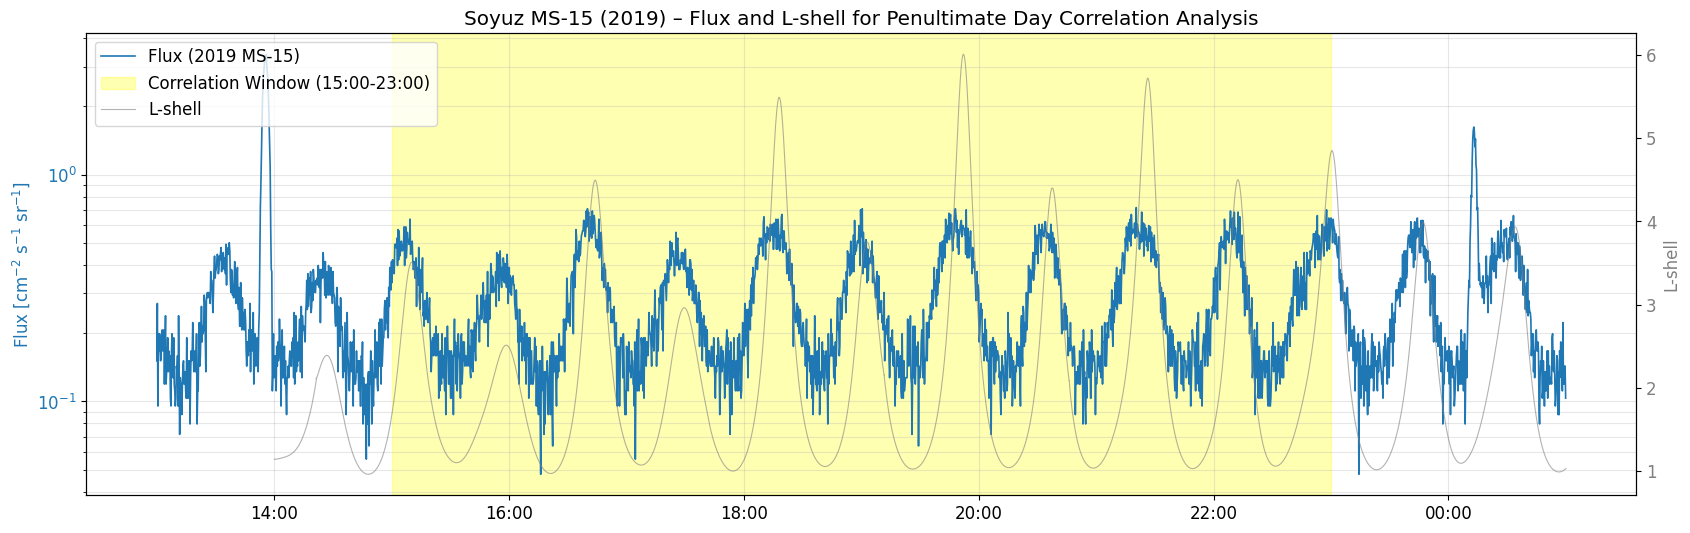

Correlation window set from 2020-02-05 15:00:00+00:00 to 2020-02-05 23:00:00+00:00


In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Define the window: Penultimate day of 2019 data (Feb 5, 2020)
tmin_corr_window = pd.Timestamp("2020-02-05 15:00:00", tz="UTC")
tmax_corr_window = pd.Timestamp("2020-02-05 23:00:00", tz="UTC")

# Define orbit data for Feb 5, 2020
orbit19_feb5 = load_orbit("orbit2019.tsv", tmin_corr_window, days=1)

# Filter flux data for visualization
z_view = rc19_last.loc[(rc19_last['corr_time'] >= tmin_corr_window - pd.Timedelta(hours=2)) &
                       (rc19_last['corr_time'] <= tmax_corr_window + pd.Timedelta(hours=2))]

# Filter orbit data for visualization
orbit_view = orbit19_feb5.loc[(orbit19_feb5['UTC'] >= tmin_corr_window - pd.Timedelta(hours=2)) &
                             (orbit19_feb5['UTC'] <= tmax_corr_window + pd.Timedelta(hours=2))]

plt.figure(figsize=(20, 6))
ax = plt.gca()

# Plot Flux on primary y-axis
ax.plot(z_view['corr_time'], z_view['flux'], color='tab:blue', lw=1.2, label='Flux (2019 MS-15)')
ax.set_yscale('log')
ax.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# Create twin axis for L-shell on secondary y-axis
ax2 = ax.twinx()
ax2.plot(orbit_view['UTC'], orbit_view['L'], color='gray', lw=0.8, alpha=0.6, label='L-shell')
ax2.set_ylabel('L-shell', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Highlight the correlation window
ax.axvspan(tmin_corr_window, tmax_corr_window, color='yellow', alpha=0.3, label='Correlation Window (15:00-23:00)')

plt.title('Soyuz MS-15 (2019) – Flux and L-shell for Penultimate Day Correlation Analysis')
plt.xlabel('UTC Time (2020-02-05)')
ax.grid(True, which='both', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.savefig("correlation_window_overview.png", dpi=300)
plt.show()

print(f"Correlation window set from {tmin_corr_window} to {tmax_corr_window}")

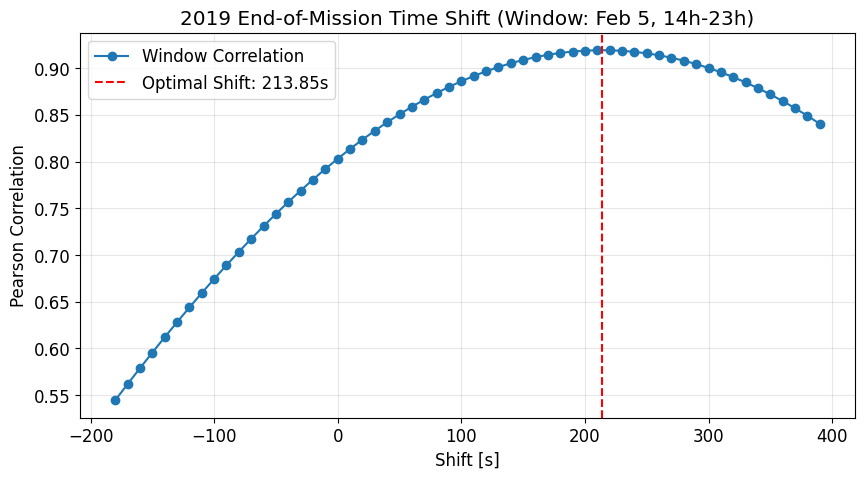

Refined Optimal Shift for 2019 End-Phase: 213.85 seconds
Maximum Correlation in window: 0.9193


In [37]:
# 1. Filter data for the specific 2019 window (Feb 5, 2020, 14:00-23:00 UTC)
tmin_win = pd.Timestamp("2020-02-05 15:00:00", tz="UTC")
tmax_win = pd.Timestamp("2020-02-05 23:00:00", tz="UTC")

rc19_win = rc19_last.loc[(rc19_last['corr_time'] >= tmin_win) & (rc19_last['corr_time'] <= tmax_win)].copy()
orbit19_win = orbit19_feb5.loc[(orbit19_feb5['UTC'] >= tmin_win - pd.Timedelta(minutes=10)) &
                              (orbit19_feb5['UTC'] <= tmax_win + pd.Timedelta(minutes=10))].copy()

# 2. Calculate correlations for a range of shifts
shifts_fine = np.arange(-180, 400, 10)
corrs19_win = [calculate_shifted_correlation(rc19_win, orbit19_win, s) for s in shifts_fine]

# 3. Find precise peak via parabolic fit
ps19_win, pc19_win, err19_win = find_precise_peak(shifts_fine, corrs19_win)

# 4. Visualization of the correlation curve
plt.figure(figsize=(10, 5))
plt.plot(shifts_fine, corrs19_win, 'o-', color='tab:blue', label='Window Correlation')
plt.axvline(ps19_win, color='red', linestyle='--', label=f'Optimal Shift: {ps19_win:.2f}s')
plt.title('2019 End-of-Mission Time Shift (Window: Feb 5, 14h-23h)')
plt.xlabel('Shift [s]')
plt.ylabel('Pearson Correlation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("end_mission_drift_analysis.png", dpi=300)
plt.show()

print(f"Refined Optimal Shift for 2019 End-Phase: {ps19_win:.2f} seconds")
print(f"Maximum Correlation in window: {pc19_win:.4f}")

### 19. Final 2019 Mission Segment with Corrected Time-Shift
Using the refined shift of **213.85 seconds**, we can now visualize the landing phase of Soyuz MS-15 with improved temporal alignment.

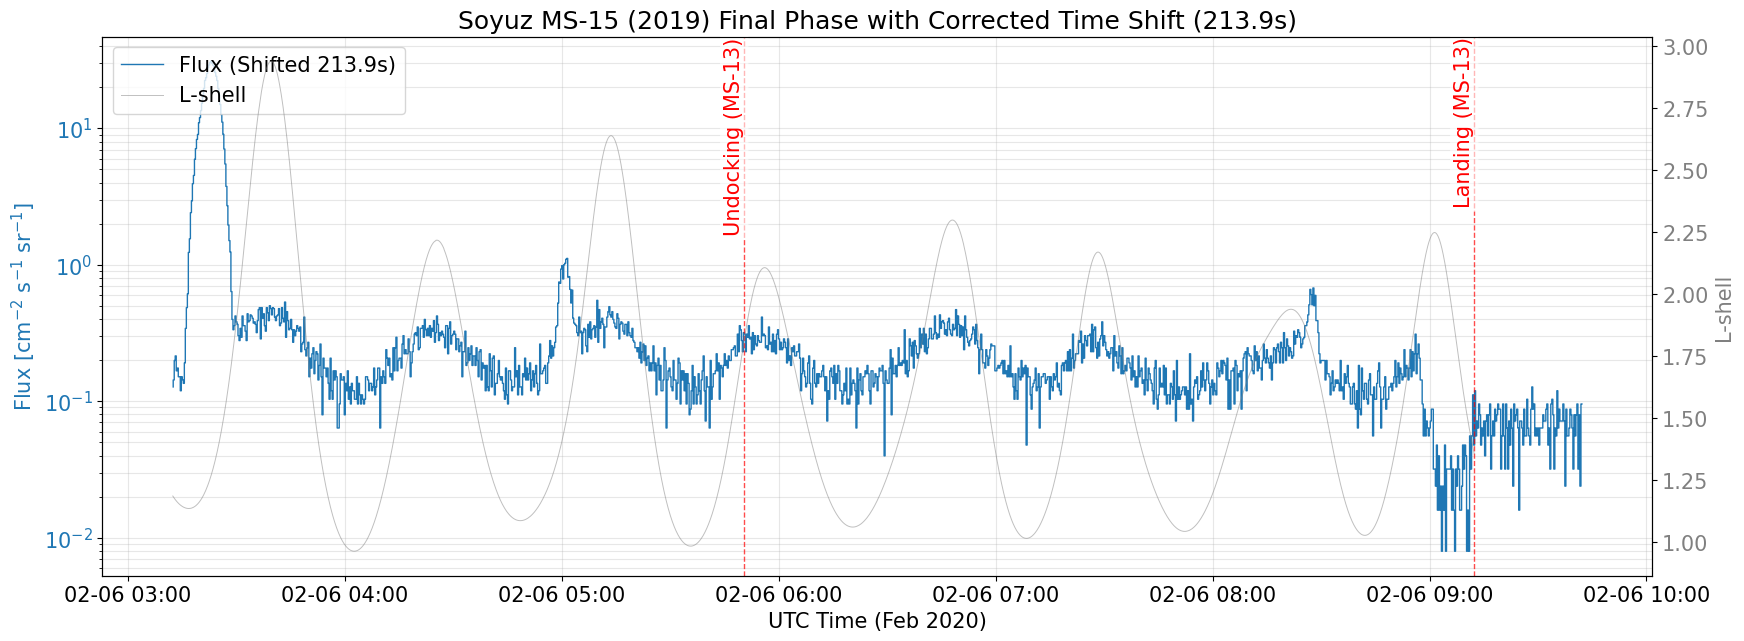

In [68]:
plt.figure(figsize=(20, 7))
ax1 = plt.gca()
matplotlib.rcParams.update({'font.size': 15})

# Apply the NEWLY discovered shift for the end-phase
shift_end_2019 = ps19_win # ~213.85s

# Filter 2019 end segment for the last 48 hours including undocking/landing
tmax_landing = events_2019['Landing (MS-13)']
tmin_view = tmax_landing - pd.Timedelta(hours=6)

# Shift the data for visualization
rc19_shifted = rc19_last.copy()
rc19_shifted['time_corr'] = rc19_shifted['corr_time'] + pd.Timedelta(seconds=shift_end_2019)

z_plot = rc19_shifted.loc[(rc19_shifted['time_corr'] >= tmin_view) & (rc19_shifted['time_corr'] <= tmax_landing + pd.Timedelta(minutes=30))]
orb_plot = orbit19_end.loc[(orbit19_end['UTC'] >= tmin_view) & (orbit19_end['UTC'] <= tmax_landing + pd.Timedelta(minutes=30))]

# Plot Flux
ax1.plot(z_plot['time_corr'], z_plot['flux'], drawstyle='steps-pre', color='tab:blue', lw=1, label=f'Flux (Shifted {shift_end_2019:.1f}s)')
ax1.set_yscale('log')
ax1.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot L-shell
ax2 = ax1.twinx()
ax2.plot(orb_plot['UTC'], orb_plot['L'], color='gray', lw=0.7, alpha=0.5, label='L-shell')
ax2.set_ylabel('L-shell', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Mark Events
draw_events(ax1, events_2019, tmin_view, tmax_landing + pd.Timedelta(minutes=30), color='red')

plt.title(f'Soyuz MS-15 (2019) Final Phase with Corrected Time Shift ({shift_end_2019:.1f}s)')
ax1.set_xlabel('UTC Time (Feb 2020)')
ax1.grid(True, which='both', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

# Combined Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')

plt.savefig("ms15_landing_final_corrected.png", dpi=300)
plt.show()

### 20. Načítání dat z přístroje DosTel2

In [39]:
import gdown
import pandas as pd

# Google Drive file IDs for DosTel2 data
FILE_ID_DOSTEL2_1 = "1jphqxV1jI178_1ZA3DY4aefFdel_CMbc" # First interval
FILE_ID_DOSTEL2_2 = "1T-TnSBT-36geq_rHJ-vN_IQ1gwruDrgk" # Second interval

print("Stahuji soubor pro první interval DosTel2...")
gdown.download(f"https://drive.google.com/uc?id={FILE_ID_DOSTEL2_1}", "dostel2_interval1.csv", quiet=False)
print("Stahuji soubor pro druhý interval DosTel2...")
gdown.download(f"https://drive.google.com/uc?id={FILE_ID_DOSTEL2_2}", "dostel2_interval2.csv", quiet=False)

print("Načítám data z prvního souboru...")
dostel2_df1 = pd.read_csv("dostel2_interval1.csv")

print("Načítám data z druhého souboru...")
dostel2_df2 = pd.read_csv("dostel2_interval2.csv")

print("První interval (dostel2_df1):")
display(dostel2_df1.head())

print("Druhý interval (dostel2_df2):")
display(dostel2_df2.head())

Stahuji soubor pro první interval DosTel2...


Downloading...
From: https://drive.google.com/uc?id=1jphqxV1jI178_1ZA3DY4aefFdel_CMbc
To: /content/dostel2_interval1.csv
100%|██████████| 19.5k/19.5k [00:00<00:00, 20.4MB/s]


Stahuji soubor pro druhý interval DosTel2...


Downloading...
From: https://drive.google.com/uc?id=1T-TnSBT-36geq_rHJ-vN_IQ1gwruDrgk
To: /content/dostel2_interval2.csv
100%|██████████| 19.7k/19.7k [00:00<00:00, 31.2MB/s]

Načítám data z prvního souboru...
Načítám data z druhého souboru...
První interval (dostel2_df1):


,timestamp,instrument_id,absorbed_dose_rate,altitude,instrument,latitude,longitude,module,spacecraft,trajectory
0,2020-10-14T05:45:00,DosTel2,5.303447,422.240041,DosTel2,44.283294,60.038174,Columbus,ISS,LEO
1,2020-10-14T05:46:35,DosTel2,6.232844,422.950697,DosTel2,47.116087,67.428257,Columbus,ISS,LEO
2,2020-10-14T05:48:28,DosTel2,7.631411,423.641175,DosTel2,49.715798,77.221594,Columbus,ISS,LEO
3,2020-10-14T05:50:00,DosTel2,7.724053,424.045956,DosTel2,51.102328,85.888859,Columbus,ISS,LEO
4,2020-10-14T05:50:08,DosTel2,8.342302,424.073727,DosTel2,51.188976,86.665409,Columbus,ISS,LEO


Druhý interval (dostel2_df2):


,timestamp,instrument_id,absorbed_dose_rate,altitude,instrument,latitude,longitude,module,spacecraft,trajectory
0,2020-10-18T04:14:25,DosTel2,7.196466,423.559188,DosTel2,49.779755,77.713374,Columbus,ISS,LEO
1,2020-10-18T04:15:00,DosTel2,6.612124,423.717178,DosTel2,50.380118,80.955892,Columbus,ISS,LEO
2,2020-10-18T04:16:17,DosTel2,7.064919,423.986283,DosTel2,51.339837,88.350394,Columbus,ISS,LEO
3,2020-10-18T04:17:57,DosTel2,7.629984,424.164086,DosTel2,51.798842,98.280465,Columbus,ISS,LEO
4,2020-10-18T04:19:37,DosTel2,8.217433,424.141586,DosTel2,51.341861,108.210759,Columbus,ISS,LEO


### 21. Porovnání dávkových příkonů DosTel2 a SPACEDOS MS-17

Timestamps v DosTel2 dataframech byly převedeny na datetime formát.


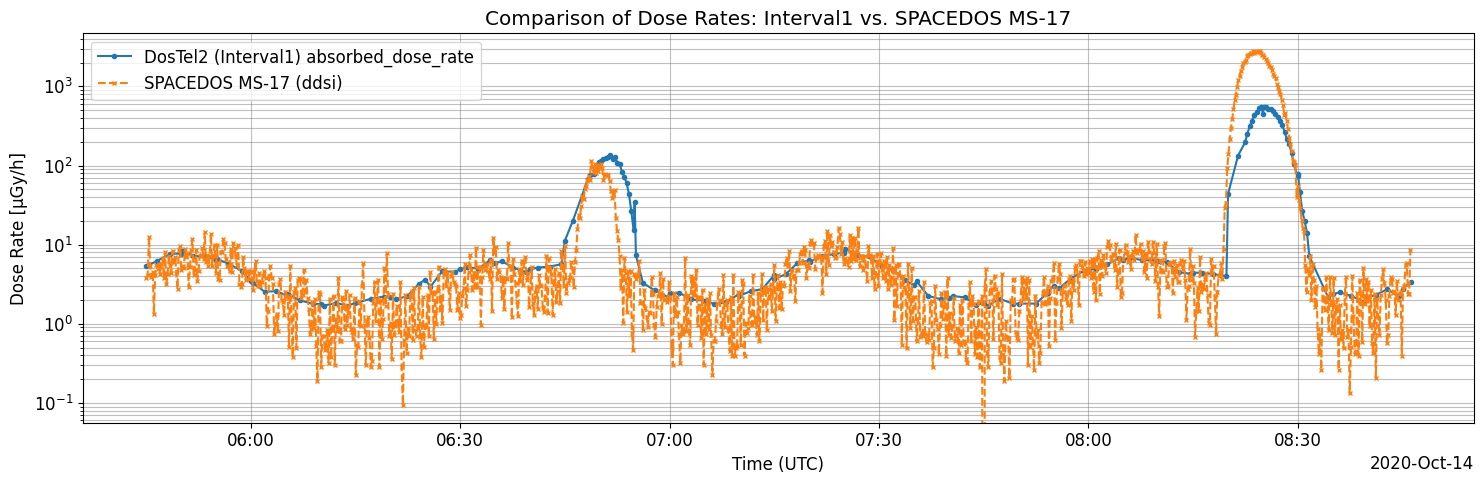

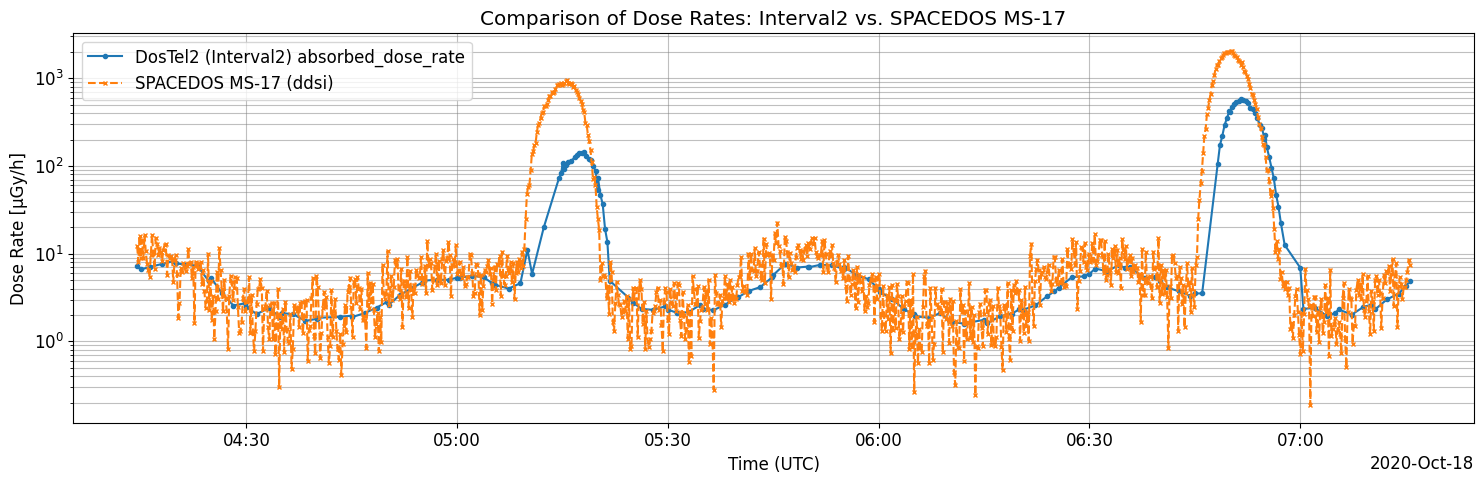

Všechny grafy pro porovnání dávkových příkonů byly vygenerovány a uloženy do samostatných souborů.


In [79]:
dostel2_df1['timestamp'] = pd.to_datetime(dostel2_df1['timestamp'], utc=True)
dostel2_df2['timestamp'] = pd.to_datetime(dostel2_df2['timestamp'], utc=True)

print("Timestamps v DosTel2 dataframech byly převedeny na datetime formát.")
# Uložíme si DataFrames a jejich názvy pro iteraci
dostel2_dataframes = [
    (dostel2_df1, "Interval1"),
    (dostel2_df2, "Interval2")
]

# Procházení každého dataframe a generování samostatného grafu
for dostel2_df, df_name in dostel2_dataframes:
    fig, ax = plt.subplots(figsize=(15, 5))
    plt.rcParams.update({'font.size': 12}) # Nastavení velikosti písma pro celou figuru

    tmin = dostel2_df['timestamp'].min()
    tmax = dostel2_df['timestamp'].max()

    # Filtrujeme data SPACEDOS pro MS-17 (rc20) do stejného časového rozsahu
    # Předpokládáme, že rc20['corr_time'] je již převedeno na datetime
    rc20_filtered = rc20.loc[(rc20['corr_time'] >= tmin) & (rc20['corr_time'] <= tmax)].copy()

    # Plot DosTel2 absorbed_dose_rate
    ax.plot(dostel2_df['timestamp'], dostel2_df['absorbed_dose_rate'],
            color='tab:blue', marker='o', linestyle='-', markersize=3, label=f'DosTel2 ({df_name}) absorbed_dose_rate')

    # Plot SPACEDOS MS-17 ddsi
    if not rc20_filtered.empty:
        ax.plot(rc20_filtered['corr_time'], rc20_filtered['ddsi'],
                color='tab:orange', marker='x', linestyle='--', markersize=3, label='SPACEDOS MS-17 (ddsi)')
    else:
        ax.text(0.5, 0.5, f"Upozornění: Žádná data SPACEDOS MS-17 nenalezena pro rozsah {tmin} - {tmax} pro {df_name}.",
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, color='red')

    ax.set_title(f'Comparison of Dose Rates: {df_name} vs. SPACEDOS MS-17')
    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('Dose Rate [µGy/h]')
    ax.set_yscale('log') # Ensure logarithmic scale for y-axis
    ax.grid(True, which='both', alpha=0.5, color='gray') # Nastavení barvy mřížky na šedou
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

    plt.tight_layout() # Upravení layoutu
    plt.savefig(f"dostel2_{df_name.lower()}.png", dpi=300)
    plt.show()

print("Všechny grafy pro porovnání dávkových příkonů byly vygenerovány a uloženy do samostatných souborů.")

In [73]:
dose_comparison_results = []

for dostel2_df, df_name in dostel2_dataframes:
    tmin = dostel2_df['timestamp'].min()
    tmax = dostel2_df['timestamp'].max()

    # Filter DosTel2 data for the current interval
    dostel2_filtered = dostel2_df.loc[(dostel2_df['timestamp'] >= tmin) & (dostel2_df['timestamp'] <= tmax)].copy()
    # Filter SPACEDOS MS-17 (rc20) data for the same time range
    rc20_filtered = rc20.loc[(rc20['corr_time'] >= tmin) & (rc20['corr_time'] <= tmax)].copy()

    # --- Calculate total dose for DosTel2 ---
    if not dostel2_filtered.empty:
        dostel2_filtered = dostel2_filtered.sort_values('timestamp')
        t_seconds_dostel2 = (dostel2_filtered['timestamp'] - tmin).dt.total_seconds().values
        y_dose_rate_dostel2 = dostel2_filtered['absorbed_dose_rate'].values
        total_dose_dostel2_ugy = np.trapezoid(y_dose_rate_dostel2, x=t_seconds_dostel2) / 3600.0
    else:
        total_dose_dostel2_ugy = np.nan

    # --- Calculate total dose for SPACEDOS MS-17 ---
    if not rc20_filtered.empty:
        rc20_filtered = rc20_filtered.sort_values('corr_time')
        t_seconds_rc20 = (rc20_filtered['corr_time'] - tmin).dt.total_seconds().values
        y_dose_rate_rc20 = rc20_filtered['ddsi'].values
        total_dose_rc20_ugy = np.trapezoid(y_dose_rate_rc20, x=t_seconds_rc20) / 3600.0
    else:
        total_dose_rc20_ugy = np.nan

    # --- Calculate factor ---
    if np.isfinite(total_dose_dostel2_ugy) and total_dose_dostel2_ugy != 0:
        spac_dostel2_factor = total_dose_rc20_ugy / total_dose_dostel2_ugy
    else:
        spac_dostel2_factor = np.nan

    # Map the interval names as requested
    if df_name == "DosTel2_Interval1":
        display_name = "Interval 1"
    elif df_name == "DosTel2_Interval2":
        display_name = "Interval 2"
    else:
        display_name = df_name # Fallback if there are other names

    dose_comparison_results.append({
        'Interval': display_name,
        'DosTel2 Total Dose [µGy]': round(total_dose_dostel2_ugy, 1),
        'SPACEDOS MS-17 Total Dose [µGy]': round(total_dose_rc20_ugy, 1),
        'SPACEDOS/DosTel2 Factor': round(spac_dostel2_factor, 1)
    })

df_dose_comparison = pd.DataFrame(dose_comparison_results)
display(df_dose_comparison)

,Interval,DosTel2 Total Dose [µGy],SPACEDOS MS-17 Total Dose [µGy],SPACEDOS/DosTel2 Factor
0,Interval 1,73.8,249.1,3.4
1,Interval 2,74.8,263.0,3.5
